# BÀI TOÁN 1: HỒI QUY (REGRESSION) - DỰ ĐOÁN CHI PHÍ Y TẾ

Trong ngành bảo hiểm y tế, chi phí khám chữa bệnh luôn là một yếu tố biến động và tiềm ẩn nhiều rủi ro. Mục tiêu cốt lõi của bài toán này là trả lời câu hỏi: "Những yếu tố nhân khẩu học, sinh học và lối sống nào ảnh hưởng mạnh mẽ nhất đến chi phí y tế của một cá nhân?". Việc xây dựng một mô hình máy học có khả năng dự báo chính xác chi phí y tế mang lại giá trị rất lớn cho doanh nghiệp. Nó giúp các công ty bảo hiểm đánh giá được mức độ rủi ro sức khỏe của từng khách hàng, từ đó đưa ra mức phí bảo hiểm (premium) phù hợp, đảm bảo tính công bằng cho người tham gia và tối ưu hóa lợi nhuận cho tổ chức.

## PHẦN 1: KHAI BÁO THƯ VIỆN VÀ KHÁM PHÁ DỮ LIỆU

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
# 1. Tải dữ liệu
df = pd.read_csv('dataset_.csv')
display(df.head())

,age,sex,bmi,children,smoker,region,medical charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.shape

(1338, 7)

In [ ]:
df.describe()

,age,bmi,children,medical charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
medical charges,0


In [ ]:
# --- Giá trị trùng lặp ---
print("\n Giá trị trùng lặp (Duplicates):")
n_dup = df.duplicated().sum()
print(f"  Số hàng bị trùng: {n_dup}")
if n_dup > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"  → Đã xóa {n_dup} hàng trùng. Còn lại: {len(df)} hàng")
else:
    print("  → Không có hàng trùng.")


 Giá trị trùng lặp (Duplicates):
  Số hàng bị trùng: 1
  → Đã xóa 1 hàng trùng. Còn lại: 1337 hàng


In [ ]:
df.shape

(1337, 7)

In [ ]:
# --- Kiểm tra miền giá trị hợp lệ ---
print("\n Kiểm tra miền giá trị hợp lệ (Domain Validation):")
checks = {
    'age'             : (18 <= df['age']) & (df['age'] <= 64),
    'bmi'             : (df['bmi'] > 0) & (df['bmi'] < 80),
    'children'        : (df['children'] >= 0),
    'medical charges' : (df['medical charges'] > 0),
    'sex'             : df['sex'].isin(['male', 'female']),
    'smoker'          : df['smoker'].isin(['yes', 'no']),
    'region'          : df['region'].isin(['northeast', 'northwest', 'southeast', 'southwest']),
}
for feat, mask in checks.items():
    n_invalid = (~mask).sum()
    status    = "✓ OK" if n_invalid == 0 else f"✗ {n_invalid} giá trị không hợp lệ"
    print(f"  {feat:<20}: {status}")


 Kiểm tra miền giá trị hợp lệ (Domain Validation):
  age                 : ✓ OK
  bmi                 : ✓ OK
  children            : ✓ OK
  medical charges     : ✓ OK
  sex                 : ✓ OK
  smoker              : ✓ OK
  region              : ✓ OK


In [ ]:
# --- Phân bố biến phân loại ---
for col in ['sex', 'smoker', 'region']:
    counts = df[col].value_counts()
    print(f"\n  {col}:")
    for val, cnt in counts.items():
        bar = '█' * int(cnt / len(df) * 40)
        print(f"    {val:<12}: {bar} ({cnt} | {cnt/len(df)*100:.1f}%)")


  sex:
    male        : ████████████████████ (675 | 50.5%)
    female      : ███████████████████ (662 | 49.5%)

  smoker:
    no          : ███████████████████████████████ (1063 | 79.5%)
    yes         : ████████ (274 | 20.5%)

  region:
    southeast   : ██████████ (364 | 27.2%)
    southwest   : █████████ (325 | 24.3%)
    northwest   : █████████ (324 | 24.2%)
    northeast   : █████████ (324 | 24.2%)


## PHẦN 2: PHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EDA)

### 1. Phân phối biến mục tiêu charges

Trong giai đoạn tiền xử lý, việc thấu hiểu và xử lý biến mục tiêu (ở đây là chi phí y tế - medical charges) đóng vai trò là nền tảng của hệ thống học máy
. Dữ liệu chi phí thường không tuân theo phân phối chuẩn mà bị lệch phải do sự xuất hiện của một nhóm nhỏ bệnh nhân có chi phí điều trị cực kỳ cao
. Nếu giữ nguyên để huấn luyện, các mô hình tuyến tính sẽ bị sai lệch.
Do đó, ta áp dụng phép biến đổi logarit tự nhiên y=log(1+x) (thông qua hàm np.log1p của Numpy). Phép biến đổi này giúp giảm thiểu tác động của các giá trị ngoại lai cực đại và làm cho sai số dự báo trở nên đồng nhất hơn trên các phân khúc giá khác nhau
. Khi đánh giá hiệu suất mô hình ở bước cuối, ta sẽ đảo ngược phép biến đổi này để trả về sai số trên đơn vị tiền tệ thực tế.

**Cơ sở toán học**: áp dụng hàm y
′
 =log(1+y) (hàm np.log1p). Phép biến đổi này nén các khoảng cách lớn ở đuôi phân phối lại. Trong toán học hồi quy, phương sai của sai số (variance of errors) cần phải đồng nhất (homoscedasticity). Việc chuyển sang không gian Logarit giúp ổn định phương sai, từ đó mô hình Linear Regression không bị thiên vị bởi các ca bệnh có chi phí quá cao
. Khi đánh giá, bạn dùng hàm y=exp(y
′
 )−1 (hàm np.expm1) để trả về USD
.

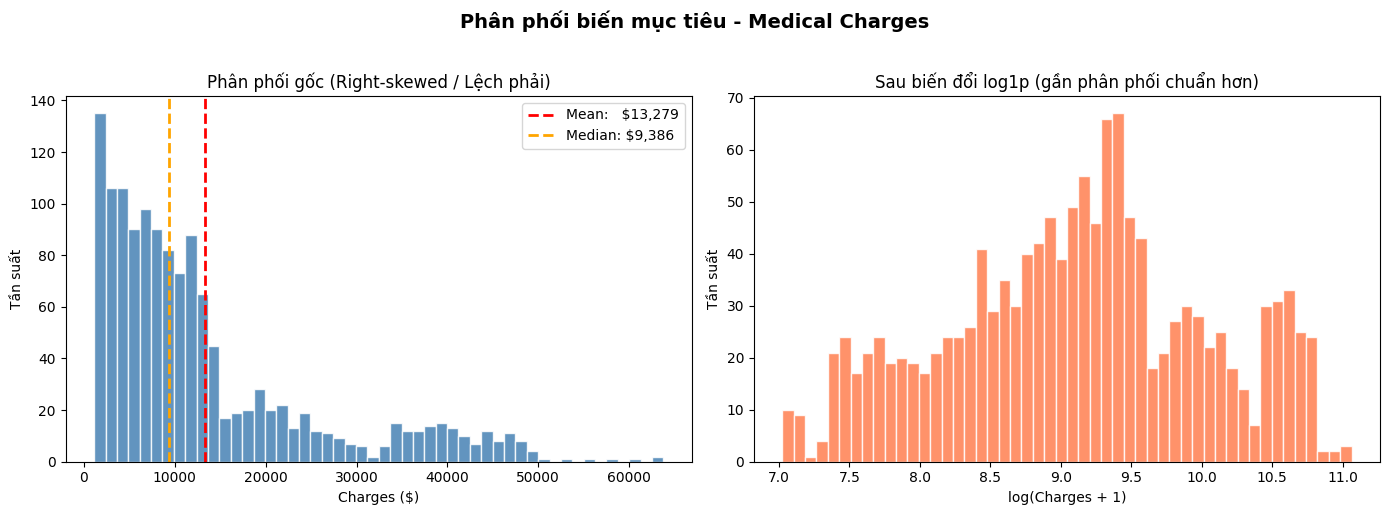

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Phân phối biến mục tiêu - Medical Charges',
             fontsize=14, fontweight='bold', y=1.02)

# Phân phối gốc
axes[0].hist(df['medical charges'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['medical charges'].mean(),   color='red',    ls='--', lw=2,
                label=f'Mean:   ${df["medical charges"].mean():,.0f}')
axes[0].axvline(df['medical charges'].median(), color='orange', ls='--', lw=2,
                label=f'Median: ${df["medical charges"].median():,.0f}')
axes[0].set_title('Phân phối gốc (Right-skewed / Lệch phải)')
axes[0].set_xlabel('Charges ($)')
axes[0].set_ylabel('Tần suất')
axes[0].legend()

# Sau log transform
axes[1].hist(np.log1p(df['medical charges']), bins=50, color='coral', edgecolor='white', alpha=0.85)
axes[1].set_title('Sau biến đổi log1p (gần phân phối chuẩn hơn)')
axes[1].set_xlabel('log(Charges + 1)')
axes[1].set_ylabel('Tần suất')

plt.tight_layout()
plt.savefig('fig1_distribution.png', bbox_inches='tight')
plt.show()



1.  **Biểu đồ bên trái (Phân phối gốc):**
    *   **Dạng phân phối:** Dữ liệu bị **lệch phải (Right-skewed)** cực kỳ mạnh. Điều này có nghĩa là phần lớn khách hàng có chi phí y tế thấp (tập trung ở vùng dưới $20,000), nhưng có một số ít trường hợp có chi phí rất cao (kéo dài đến tận 60,000).

    *   **Sự chênh lệch Mean và Median:** Đường Mean (Trung bình - màu đỏ) nằm bên phải đường Median (Trung vị - màu cam). Điều này xác nhận sự hiện diện của các giá trị ngoại lai (outliers) phía bên phải đã kéo giá trị trung bình lên cao hơn so với mức phổ biến của dữ liệu.
    *   **Thách thức đối với mô hình:** Các mô hình tuyến tính thường gặp khó khăn với dữ liệu lệch vì chúng giả định sai số tuân theo phân phối chuẩn. Nếu để nguyên, mô hình sẽ dễ bị "bias" (thiên vị) bởi các ca bệnh có chi phí cực lớn.

2.  **Biểu đồ bên phải (Sau biến đổi log1p):**
    *   **Hiệu quả biến đổi:** Sau khi áp dụng phép toán $log(1+x)$, phân phối của dữ liệu đã thay đổi hình dạng rõ rệt, trở nên đối xứng hơn và rất gần với **Phân phối chuẩn (Normal Distribution)**.
    *   **Lợi ích:** Việc đưa dữ liệu về dạng chuẩn giúp ổn định phương sai, giảm bớt tác động của các giá trị cực đại mà không cần phải xóa bỏ chúng. Điều này giúp các thuật toán hồi quy hoạt động hiệu quả hơn, dự báo chính xác hơn trên toàn bộ dải dữ liệu.



Nhận xét:
*   Phân phối gốc lệch phải mạnh: Mean ($13,270) > Median ($9,382)
*   Phần lớn người có chi phí $1,000–$20,000
*   Một nhóm nhỏ có chi phí rất cao (>$40,000) — outliers
*   Sau biến đổi log1p: phân phối gần chuẩn hơn, giúp cải thiện
     hiệu suất mô hình tuyến tính

### 2. Charges theo từng đặc trưng phân loại

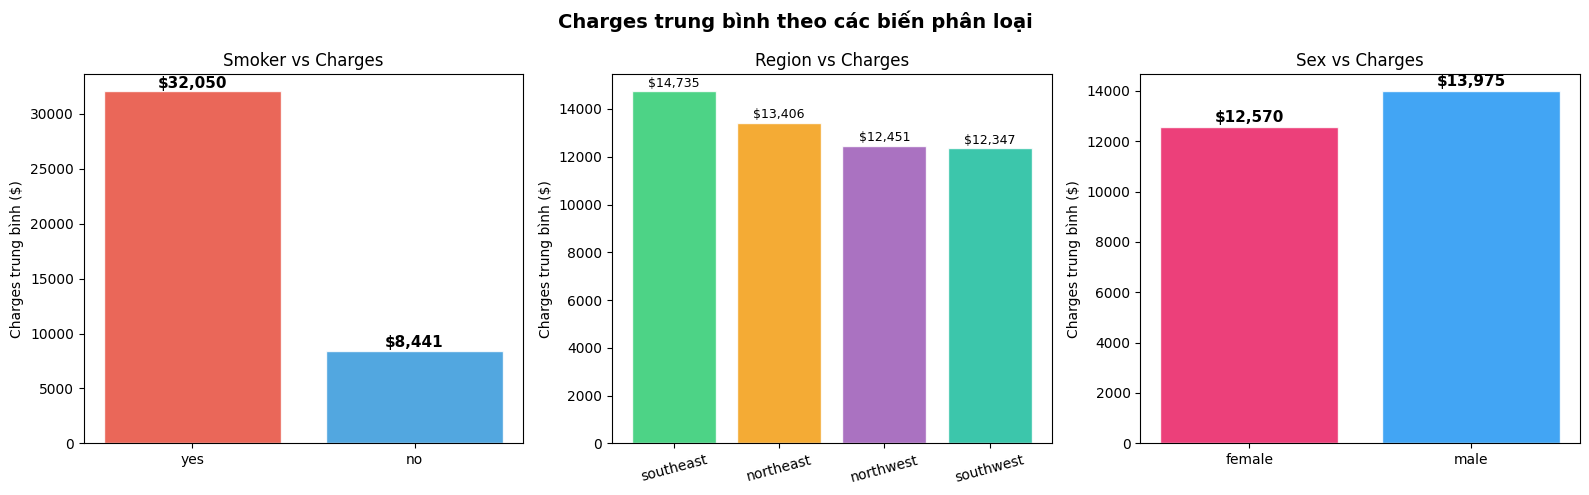

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Charges trung bình theo các biến phân loại',
             fontsize=14, fontweight='bold')

# Smoker
smoker_avg = df.groupby('smoker')['medical charges'].mean().sort_values(ascending=False)
bars0 = axes[0].bar(smoker_avg.index, smoker_avg.values,
                    color=['#e74c3c', '#3498db'], alpha=0.85, edgecolor='white')
axes[0].set_title('Smoker vs Charges')
axes[0].set_ylabel('Charges trung bình ($)')
for bar in bars0:
    axes[0].text(bar.get_x() + bar.get_width()/2.,
                 bar.get_height() + 300,
                 f'${bar.get_height():,.0f}',
                 ha='center', fontweight='bold', fontsize=11)

# Region
region_avg = df.groupby('region')['medical charges'].mean().sort_values(ascending=False)
colors_r = ['#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']
bars1 = axes[1].bar(region_avg.index, region_avg.values,
                    color=colors_r, alpha=0.85, edgecolor='white')
axes[1].set_title('Region vs Charges')
axes[1].set_ylabel('Charges trung bình ($)')
axes[1].tick_params(axis='x', rotation=15)
for bar in bars1:
    axes[1].text(bar.get_x() + bar.get_width()/2.,
                 bar.get_height() + 200,
                 f'${bar.get_height():,.0f}',
                 ha='center', fontsize=9)

# Sex
sex_avg = df.groupby('sex')['medical charges'].mean()
bars2 = axes[2].bar(sex_avg.index, sex_avg.values,
                    color=['#e91e63', '#2196f3'], alpha=0.85, edgecolor='white')
axes[2].set_title('Sex vs Charges')
axes[2].set_ylabel('Charges trung bình ($)')
for bar in bars2:
    axes[2].text(bar.get_x() + bar.get_width()/2.,
                 bar.get_height() + 200,
                 f'${bar.get_height():,.0f}',
                 ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('fig2_charges_by_category.png', bbox_inches='tight')
plt.show()

Nhận xét:
*   Smoker=yes: chi phí TB khoảng 32,050 gấp gần 4 lần Smoker=no (8,441)
     → Hút thuốc là yếu tố ảnh hưởng mạnh nhất
*   Southeast có chi phí cao nhất, Southwest thấp nhất
*   Nam giới có chi phí TB cao hơn nữ giới một chút ($13,957 vs $12,570)

### 3. Scatter plots - Age, BMI theo Medical Charges

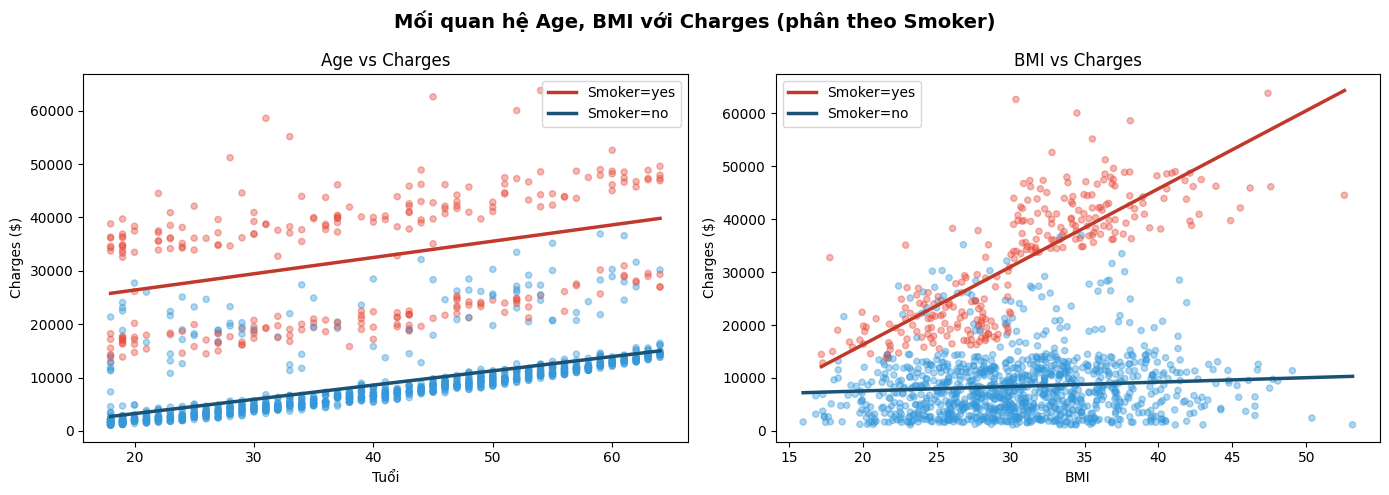

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Mối quan hệ Age, BMI với Charges (phân theo Smoker)',
             fontsize=14, fontweight='bold')

colors_map = df['smoker'].map({'yes': '#e74c3c', 'no': '#3498db'})

# Age vs Charges
sc0 = axes[0].scatter(df['age'], df['medical charges'], c=colors_map, alpha=0.4, s=20)
axes[0].set_title('Age vs Charges')
axes[0].set_xlabel('Tuổi')
axes[0].set_ylabel('Charges ($)')
# Trendlines
for label, color in zip(['yes', 'no'], ['#c0392b', '#1a5276']):
    sub = df[df['smoker'] == label]
    z = np.polyfit(sub['age'], sub['medical charges'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(sub['age'].min(), sub['age'].max(), 100)
    axes[0].plot(x_line, p(x_line), color=color, lw=2.5,
                 label=f'Smoker={label}')
axes[0].legend()

# BMI vs Charges
axes[1].scatter(df['bmi'], df['medical charges'], c=colors_map, alpha=0.4, s=20)
axes[1].set_title('BMI vs Charges')
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Charges ($)')
for label, color in zip(['yes', 'no'], ['#c0392b', '#1a5276']):
    sub = df[df['smoker'] == label]
    z = np.polyfit(sub['bmi'], sub['medical charges'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(sub['bmi'].min(), sub['bmi'].max(), 100)
    axes[1].plot(x_line, p(x_line), color=color, lw=2.5,
                 label=f'Smoker={label}')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig3_scatter_age_bmi.png', bbox_inches='tight')
plt.show()


Cặp biểu đồ phân tán trên cung cấp cái nhìn sâu sắc về cách các yếu tố sinh học (Tuổi tác, Chỉ số khối cơ thể) tương tác với lối sống (Tình trạng hút thuốc) để quyết định chi phí y tế (`medical charges`):

#### 1. Biểu đồ Tuổi tác và Chi phí y tế ($Age\ vs\ Charges$)

* **Xu hướng chung:** Cả hai nhóm người hút thuốc (màu đỏ) và không hút thuốc (màu xanh) đều cho thấy một xu hướng tuyến tính đi lên rõ rệt. Điều này khẳng định quy luật tự nhiên: **Tuổi càng cao, chi phí y tế càng tăng** do các rủi ro về sức khỏe tích lũy theo thời gian.
* **Tác động mạnh mẽ của việc hút thuốc:** Đường hồi quy của nhóm hút thuốc nằm cao hơn rất nhiều so với nhóm không hút thuốc. Ngay cả khi còn rất trẻ, một người hút thuốc đã phải chi trả mức chi phí y tế cao hơn hẳn so với những người lớn tuổi nhưng không hút thuốc.
* **Tốc độ tăng chi phí:** Độ dốc của đường hồi quy màu đỏ lớn hơn đường màu xanh, cho thấy tốc độ tăng chi phí theo độ tuổi ở người hút thuốc diễn ra nhanh hơn và nghiêm trọng hơn.
* **Sự phân cụm dữ liệu:** Dữ liệu trên biểu đồ tạo thành ba dải (tầng) riêng biệt. Điều này gợi ý rằng ngoài tuổi tác và việc hút thuốc, còn có các yếu tố bệnh lý nền hoặc mức độ/tần suất hút thuốc khác nhau ảnh hưởng và phân loại khách hàng vào các mức chi phí khác nhau.

#### 2. Biểu đồ Chỉ số khối cơ thể và Chi phí y tế ($BMI\ vs\ Charges$)

* **Đối với nhóm không hút thuốc (Màu xanh):** Đường hồi quy gần như nằm ngang hoặc chỉ dốc lên rất nhẹ. Điều này cho thấy đối với người có lối sống lành mạnh (không hút thuốc), chỉ số $BMI$ cao đơn thuần chưa gây ra sự bùng nổ hay đột biến về chi phí y tế ngay lập tức.
* **Đối với nhóm hút thuốc (Màu đỏ):** Cục diện thay đổi hoàn toàn với một đường hồi quy có độ dốc cực lớn. Đặc biệt, khi chỉ số $BMI$ vượt quá ngưỡng $30$ (ngưỡng xác định béo phì), chi phí y tế của người hút thuốc tăng vọt thẳng đứng, đạt mức từ $\$30,000$ đến hơn $\$60,000$.
* **Hiệu ứng cộng hưởng ($Interaction\ Effect$):** Đây là minh chứng rõ ràng nhất cho hiện tượng tương tác biến trong học máy:

$$\text{Hút thuốc} + \text{Béo phì (BMI} > 30\text{)} = \text{Chi phí y tế cực đại}$$



Nếu chỉ béo phì mà không hút thuốc, chi phí vẫn nằm trong tầm kiểm soát; nhưng khi kết hợp cả hai yếu tố rủi ro này, rủi ro tài chính bảo hiểm và sức khỏe sẽ bị đẩy lên mức tối đa.

 **Kết luận tổng quan:** Trong khi tuổi tác là yếu tố rủi ro sinh học tất yếu tăng dần theo thời gian, thì **sự kết hợp giữa chỉ số thể hình kém ($BMI$ béo phì) và lối sống không lành mạnh (hút thuốc)** mới là tác nhân chính gây ra những cú sốc tài chính, đẩy chi phí y tế lên các mức cao đột biến ($outliers$) trong bộ dữ liệu này.

### 4. Boxplot - Charges theo Children & Violin Plot

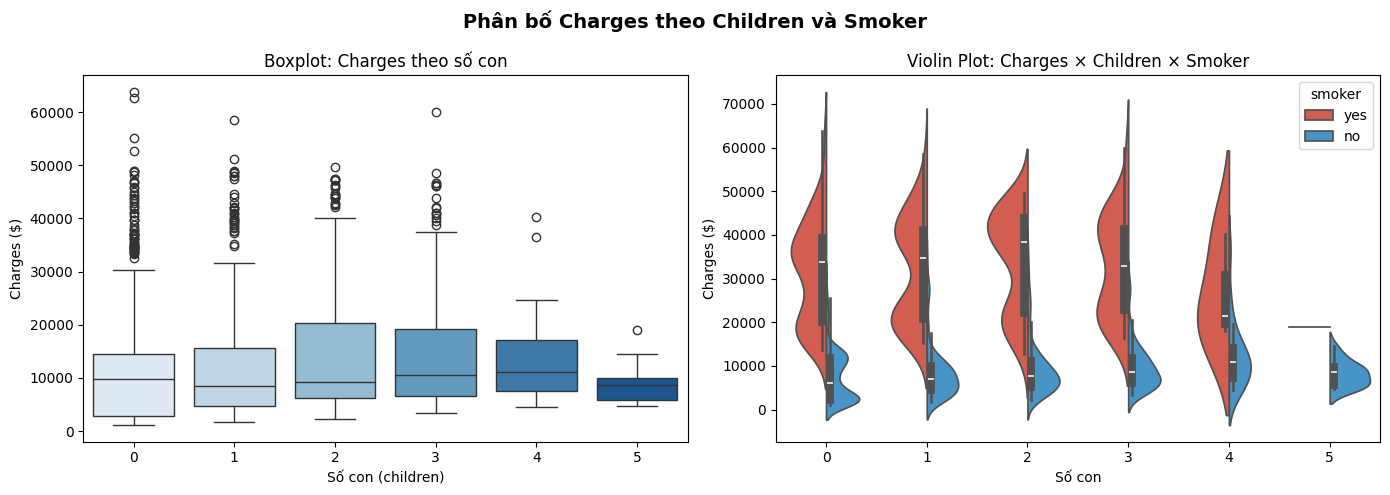

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Phân bố Charges theo Children và Smoker',
             fontsize=14, fontweight='bold')

sns.boxplot(x='children', y='medical charges', data=df, ax=axes[0], palette='Blues')
axes[0].set_title('Boxplot: Charges theo số con')
axes[0].set_xlabel('Số con (children)')
axes[0].set_ylabel('Charges ($)')

sns.violinplot(x='children', y='medical charges', hue='smoker',
               data=df, split=True, ax=axes[1],
               palette={'yes': '#e74c3c', 'no': '#3498db'})
axes[1].set_title('Violin Plot: Charges × Children × Smoker')
axes[1].set_xlabel('Số con')
axes[1].set_ylabel('Charges ($)')

plt.tight_layout()
plt.savefig('fig4_boxplot_violin.png', bbox_inches='tight')
plt.show()



Cặp trực quan hóa này giúp chúng ta đánh giá tác động của số lượng con cái (`children`) đối với chi phí y tế (`medical charges`), đồng thời bóc tách sâu hơn thông qua yếu tố lối sống (Tình trạng hút thuốc - `smoker`).

#### 1. Biểu đồ hộp (Boxplot: Charges theo số con)

* **Xu hướng trung vị (Median):** Đường trung vị của chi phí y tế nhìn chung khá ổn định và có xu hướng tăng nhẹ từ nhóm 0 con đến 3 con. Điều này hợp lý vì khi quy mô gia đình tăng lên, các nhu cầu và tần suất chăm sóc y tế cho con cái cũng tăng theo.
* **Sự sụt giảm ở nhóm nhiều con (4-5 con):** Biểu đồ cho thấy mức chi phí trung vị ở nhóm có 4 hoặc 5 con lại có dấu hiệu đi xuống hoặc dao động mạnh. Điều này có thể được giải thích bởi yếu tố cỡ mẫu (số lượng người có 4-5 con trong bộ dữ liệu thường ít hơn nhiều so với nhóm 0-2 con), hoặc do những gia đình đông con có xu hướng thắt chặt chi tiêu và tối ưu hóa các gói bảo hiểm gia đình.
* **Giá trị ngoại lai (Outliers):** Ở tất cả các nhóm số con, đặc biệt là từ 0 đến 3 con, xuất hiện rất nhiều điểm dữ liệu ngoại lai phía trên (các chấm đen vượt ngoài râu hộp). Điều này chứng tỏ số lượng con cái không phải là nguyên nhân trực tiếp gây ra các ca có chi phí cực đại, mà có những biến số khác đang chi phối mạnh mẽ hơn.

#### 2. Biểu đồ vĩ cầm (Violin Plot: Charges × Children × Smoker)

Khi tách biệt dữ liệu theo tình trạng hút thuốc (Màu đỏ: Có hút thuốc / Màu xanh: Không hút thuốc), bản chất của các giá trị ngoại lai ở biểu đồ Boxplot đã được làm sáng tỏ:

* **Sự phân tách chi phí tuyệt đối:** Ở bất kỳ số lượng con nào (từ 0 đến 5), hình dáng vĩ cầm luôn bị chia làm hai thế giới hoàn toàn tách biệt:
* **Nhóm màu xanh (Không hút thuốc):** Phần "bụng" phình to tập trung ở vùng đáy (dưới $15,000). Điều này cho thấy phần lớn người không hút thuốc đều có chi phí y tế thấp và ổn định, bất kể họ có bao nhiêu con.

* **Nhóm màu đỏ (Có hút thuốc):** Thân vĩ cầm kéo dài và phình to ở phân khúc cao (từ 15,000 đến trên $45,000). Lối sống không lành mạnh đẩy toàn bộ phân phối chi phí của nhóm này lên một mặt bằng giá mới.


* **Mật độ phân phối:** Đối với nhóm người hút thuốc, biểu đồ vĩ cầm thường xuất hiện cấu trúc "hai đỉnh" (bimodal distribution). Một đỉnh nhỏ ở khoảng 20,000 và một đỉnh lớn hơn ở vùng $40,000. Điều này cho thấy số con không làm thay đổi hành vi chi tiêu y tế của người hút thuốc, mà chính sự kết hợp của hút thuốc với các rủi ro khác (như béo phì, bệnh nền) mới phân lập họ vào các mức chi phí cực cao này.

**Kết luận tổng quan:** Số lượng con cái có làm biến động nhẹ mức chi phí y tế cơ bản, nhưng **không phải là yếu tố quyết định** tạo ra đột biến. Tình trạng hút thuốc mới là biến số cốt lõi làm thay đổi hoàn toàn phân phối chi phí, đẩy rủi ro tài chính lên mức cao ở mọi nhóm đối tượng nhân khẩu học.

### 5. Correlation Heatmap

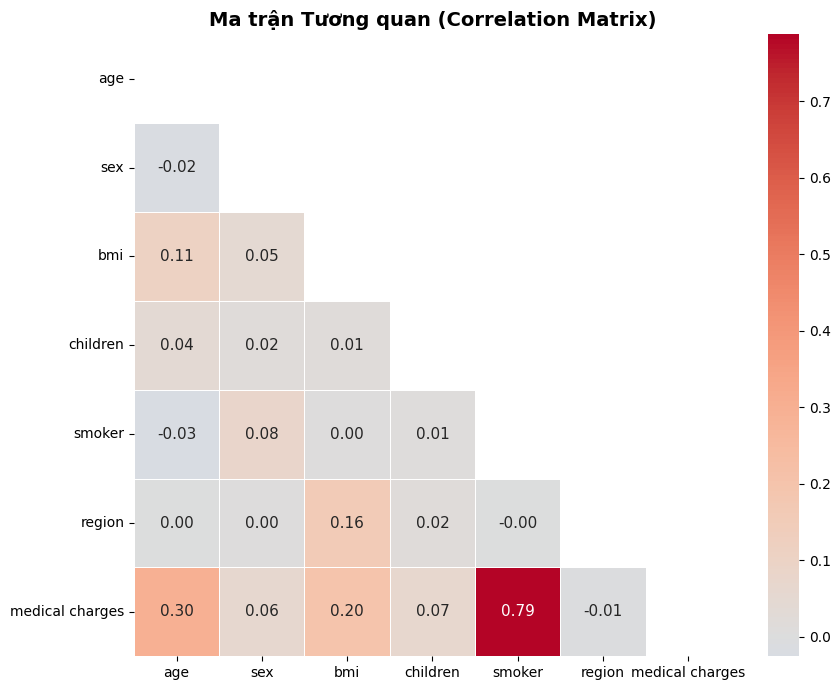

In [ ]:
from sklearn.preprocessing import LabelEncoder

df_enc = df.copy()
le_tmp = LabelEncoder()
for col in ['sex', 'smoker', 'region']:
    df_enc[col] = le_tmp.fit_transform(df_enc[col])

fig, ax = plt.subplots(figsize=(9, 7))
corr = df_enc.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, mask=mask, ax=ax, linewidths=0.5, annot_kws={'size': 11})
ax.set_title('Ma trận Tương quan (Correlation Matrix)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_correlation_heatmap.png', bbox_inches='tight')
plt.show()



Biểu đồ Heatmap trên giúp chúng ta định lượng mối quan hệ tuyến tính giữa các biến số. Hệ số tương quan (r) nằm trong khoảng từ -1 đến 1, trong đó giá trị tuyệt đối càng gần 1 thì mối quan hệ càng mạnh:

1.  **Yếu tố quyết định nhất - Smoker (r = 0.79):**
    *   Đây là biến có tương quan thuận mạnh nhất với chi phí y tế. Điều này khẳng định lại các quan sát trước đó: tình trạng hút thuốc là chỉ báo quan trọng nhất để dự báo một người sẽ phải chi trả bao nhiêu cho dịch vụ y tế.

2.  **Tác động của Tuổi tác (r = 0.30):**
    *   Tuổi tác có mức tương quan thuận trung bình. Khi tuổi tăng lên, các rủi ro về sức khỏe tích lũy dẫn đến chi phí y tế cũng tăng theo một cách tự nhiên.

3.  **BMI và các yếu tố khác:**
    *   **BMI (r = 0.20):** Có tương quan yếu với chi phí. Điều này có vẻ mâu thuẫn với biểu đồ scatter plot trước đó, nhưng lý do là vì BMI chỉ thực sự gây đột biến chi phí khi kết hợp với hút thuốc. Trong ma trận tương quan đơn lẻ, sự kết hợp này bị làm mờ đi.
    *   **Số con (Children) (r = 0.07):** Hầu như không có mối tương quan tuyến tính đáng kể nào với chi phí.

4.  **Kiểm tra Đa cộng tuyến (Multicollinearity):**
    *   Các biến độc lập (age, bmi, children, smoker...) có hệ số tương quan với nhau rất thấp (thường < 0.1). Đây là một tín hiệu rất tốt cho mô hình **Linear Regression**, vì nó cho thấy không có hiện tượng các biến đầu vào bị chồng chéo thông tin, giúp các hệ số hồi quy ổn định và đáng tin cậy hơn.

**Kết luận:** Mô hình dự báo nên tập trung đặc biệt vào biến `smoker`, `age` và `bmi`. Các biến như `sex` hay `region` có thể đóng vai trò thứ yếu trong việc tinh chỉnh độ chính xác.

## PHẦN 3: TIỀN XỬ LÝ DỮ LIỆU

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

### 1. Xử lý Outlier bằng IQR Capping

  bmi                 : Q1=26.29, Q3=34.70, IQR=8.41
                        lower_fence=13.67, upper_fence=47.32
                        → 9 outlier bị cap (clip)

  medical charges     : Q1=4746.34, Q3=16657.72, IQR=11911.37
                        lower_fence=-13120.72, upper_fence=34524.78
                        → 139 outlier bị cap (clip)

  Kích thước sau xử lý outlier: (1337, 7)  (không xóa hàng)


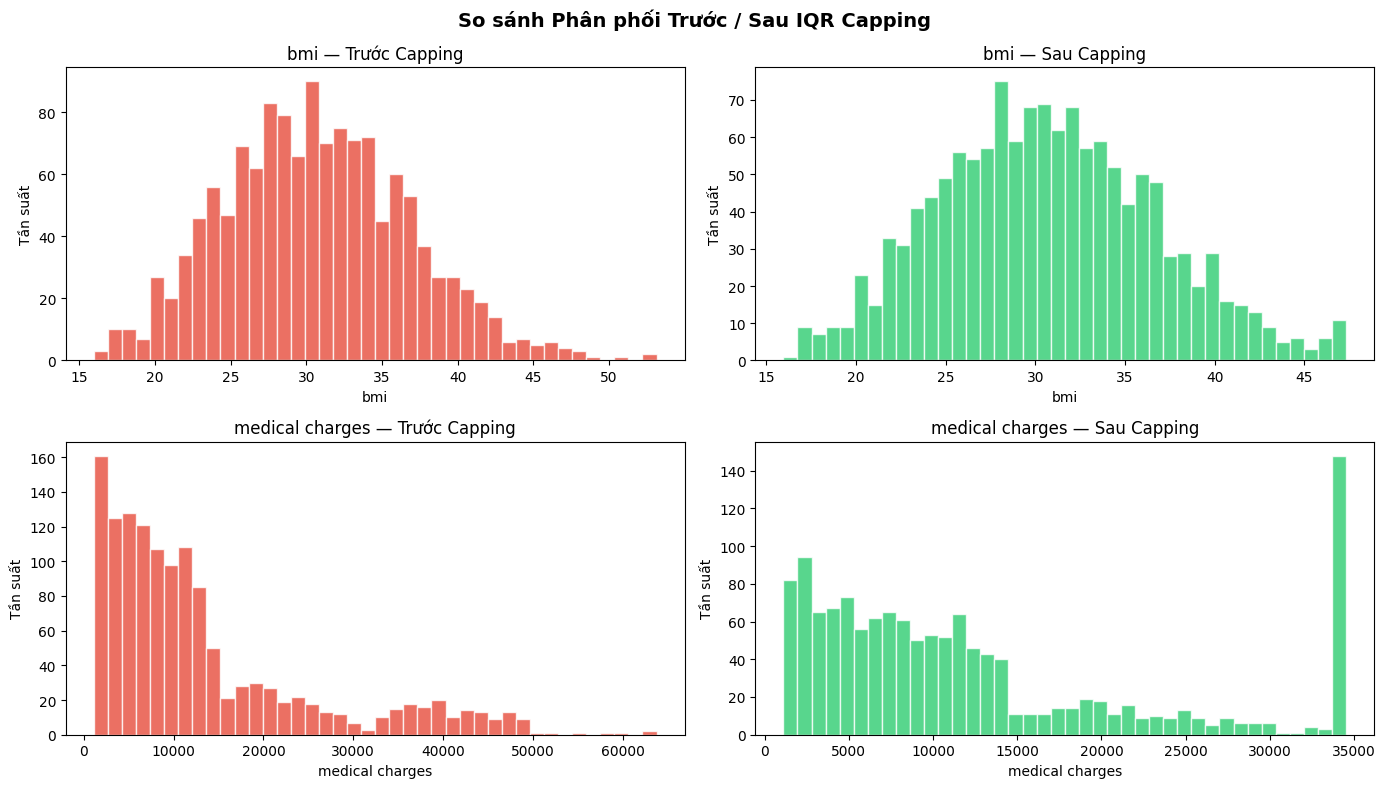

In [ ]:
# Áp dụng IQR capping cho các biến số liên tục
# Công thức: giá trị nằm ngoài [Q1 - 1.5*IQR, Q3 + 1.5*IQR] bị kéo về fence
# → giữ lại hàng, không xóa → tránh mất dữ liệu

df_clean = df.copy()
num_cols_outlier = ['bmi', 'medical charges']   # age, children phân phối tự nhiên không cần cap

for col in num_cols_outlier:
    Q1  = df_clean[col].quantile(0.25)
    Q3  = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)
    print(f"  {col:<20}: Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
    print(f"  {'':20}  lower_fence={lower:.2f}, upper_fence={upper:.2f}")
    print(f"  {'':20}  → {n_out} outlier bị cap (clip)\n")

print(f"  Kích thước sau xử lý outlier: {df_clean.shape}  (không xóa hàng)")

# Vẽ so sánh trước/sau outlier
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('So sánh Phân phối Trước / Sau IQR Capping', fontsize=14, fontweight='bold')

for i, col in enumerate(num_cols_outlier):
    axes[i][0].hist(df[col], bins=40, color='#e74c3c', edgecolor='white', alpha=0.8)
    axes[i][0].set_title(f'{col} — Trước Capping')
    axes[i][0].set_xlabel(col)
    axes[i][0].set_ylabel('Tần suất')

    axes[i][1].hist(df_clean[col], bins=40, color='#2ecc71', edgecolor='white', alpha=0.8)
    axes[i][1].set_title(f'{col} — Sau Capping')
    axes[i][1].set_xlabel(col)
    axes[i][1].set_ylabel('Tần suất')

plt.tight_layout()
plt.savefig('fig_outlier_capping.png', bbox_inches='tight')
plt.show()



Cặp biểu đồ trên so sánh sự thay đổi của phân phối dữ liệu trước và sau khi áp dụng kỹ thuật **IQR Capping** (còn gọi là Winsorization) cho hai biến: `bmi` và `medical charges`.

1.  **Biến BMI:**
    *   **Trước khi xử lý:** Phân phối của BMI khá cân đối nhưng có một vài giá trị ngoại lai nằm ở phía cực cao (vượt quá 47). Những giá trị này có thể gây nhiễu cho các thuật toán nhạy cảm với biên độ.
    *   **Sau khi xử lý:** Các giá trị vượt quá ngưỡng `upper_fence` (47.32) đã được kéo về đúng giá trị ngưỡng này. Điều này giải thích tại sao ở biểu đồ bên phải, ta thấy một cột cao vọt xuất hiện ở cuối dải dữ liệu. Phân phối chính vẫn được giữ nguyên, đảm bảo không mất thông tin quan trọng.

2.  **Biến Medical Charges (Chi phí y tế):**
    *   **Trước khi xử lý:** Đây là biến có vấn đề nghiêm trọng nhất với 139 điểm dữ liệu ngoại lai. Phân phối bị lệch phải cực mạnh với một "đuôi" dài kéo đến tận hơn $60,000.

    *   **Sau khi xử lý:** Tất cả các ca có chi phí vượt quá ngưỡng hàng rào trên ($34,524) đã được thu gom về mức trần này. Biểu đồ sau khi capping cho thấy dữ liệu tập trung hơn, giúp mô hình hồi quy không bị "kéo lệch" bởi những trường hợp chi phí quá đặc biệt.



### 2. Tách đặc trưng & nhãn, chia Train/Test

In [ ]:
CAT_COLS = ['sex', 'smoker', 'region']   # biến phân loại → OneHotEncoder
NUM_COLS = ['age', 'bmi', 'children']    # biến số → StandardScaler

X = df_clean.drop('medical charges', axis=1)
y = df_clean['medical charges']

print(f"  X.shape = {X.shape}")
print(f"  Biến số (StandardScaler)  : {NUM_COLS}")
print(f"  Biến phân loại (OHE)      : {CAT_COLS}")
print(f"  y — min=${y.min():,.2f}, max=${y.max():,.2f}, mean=${y.mean():,.2f}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print(f"\n  X_train: {X_train.shape}  |  X_test: {X_test.shape}")

  X.shape = (1337, 6)
  Biến số (StandardScaler)  : ['age', 'bmi', 'children']
  Biến phân loại (OHE)      : ['sex', 'smoker', 'region']
  y — min=$1,121.87, max=$34,524.78, mean=$12,491.16

  X_train: (1069, 6)  |  X_test: (268, 6)




1. **Tách đặc trưng (X) và Nhãn (y)**:
    *   **X (Features)**: Là tập hợp các biến đầu vào dùng để dự báo. Chúng ta loại bỏ cột `medical charges` khỏi dữ liệu gốc để lấy các thông tin như tuổi, giới tính, BMI, số con, tình trạng hút thuốc và vùng miền.
    *   **y (Target)**: Là biến mục tiêu chúng ta muốn dự báo (`medical charges`). Mô hình sẽ học mối liên hệ giữa các đặc trưng trong **X** để đưa ra con số **y** chính xác nhất.

2. **Danh sách cột xử lý**:
    *   **NUM_COLS**: Gồm `age`, `bmi`, `children`. Đây là các biến số liên tục, sau này sẽ được chuẩn hóa bằng `StandardScaler` để đưa về cùng một thang đo (giúp thuật toán hội tụ nhanh hơn).
    *   **CAT_COLS**: Gồm `sex`, `smoker`, `region`. Đây là các biến định danh (văn bản), cần được chuyển đổi sang dạng số thông qua `OneHotEncoder` để máy tính có thể tính toán.

3. **Chia tập Train/Test (80/20)**:
    *   Chúng ta sử dụng hàm `train_test_split` với tỷ lệ `test_size=0.2`.
    *   **Tập Train (80%)**: Dùng để "dạy" mô hình học các quy luật của dữ liệu.
    *   **Tập Test (20%)**: Đóng vai trò là dữ liệu mới hoàn toàn mà mô hình chưa từng thấy. Chúng ta dùng tập này để đánh giá khách quan xem mô hình dự báo tốt đến đâu trên thực tế.
    *   **random_state=42**: Con số này giúp cố định việc chia dữ liệu. Mỗi khi chạy lại code, kết quả chia vẫn giữ nguyên, giúp chúng ta so sánh các mô hình một cách công bằng.

### 3. ColumnTransformer + OneHotEncoder



#### **1. Tại sao lại chọn StandardScaler cho bài toán này?**

* **Cân bằng thang đo (Scale) giữa các biến:** Tập dữ liệu y tế này chứa các biến số có khoảng giá trị rất lệch nhau, bao gồm `age` (18 - 64 tuổi), `bmi` (15 - 53), và `children` (0 - 5 con). Nếu giữ nguyên thang đo gốc, các mô hình hồi quy tuyến tính hoặc mô hình dựa trên khoảng cách sẽ bị "thiên vị", vô tình coi các biến có trị số lớn quan trọng hơn và gán trọng số (coefficients) sai lệch cho chúng.
* **Đồng bộ với biến mục tiêu (Target variable):** Ở bước trước, biến mục tiêu `medical charges` đã được biến đổi bằng hàm `np.log1p` để đưa về dạng phân phối gần chuẩn nhằm ổn định phương sai sai số. Việc đưa các biến độc lập số về dạng phân phối chuẩn bằng Z-score tạo ra sự đồng bộ cấu trúc tối ưu, giúp mô hình đạt hiệu suất cao nhất.
* **Hỗ trợ hội tụ Gradient Descent:** Đối với các thuật toán tối ưu hoặc các mô hình hồi quy có thành phần phạt (Regularization như Ridge/Lasso), dữ liệu có cùng tỷ lệ giúp hàm mất mát đối xứng hơn, thuật toán tìm điểm tối ưu nhanh hơn và tránh được hiện tượng dao động vô hạn.

#### **2. Phân tích so sánh với các phương pháp định cỡ khác**

Để thấy rõ tính tối ưu của `StandardScaler`,  ta cần đặt nó trong tương quan so sánh với hai phương pháp phổ biến khác là `MinMaxScaler` và `RobustScaler`.

Đối với **MinMaxScaler**, phương pháp này tiến hành nén dữ liệu một cách nghiêm ngặt vào khoảng cố định từ $[0, 1]$ dựa trên giá trị nhỏ nhất và lớn nhất. Tuy nhiên, `MinMaxScaler` rất nhạy cảm và dễ bị ảnh hưởng nặng nề bởi các giá trị ngoại lai (outliers). Trong tập dữ liệu này, biến `bmi` xuất hiện những giá trị béo phì đặc biệt lên tới 53.13 (đây là các outlier tự nhiên mang tính bệnh lý). Nếu sử dụng `MinMaxScaler`, các dải BMI của người bình thường (từ 18 đến 25) sẽ bị bóp nghẹt lại thành một cụm siêu nhỏ sát số 0, làm mất đi chi tiết phân hóa đặc trưng và khiến mô hình rất khó học.

Đối với **RobustScaler**, công cụ này sử dụng Trung vị (Median) và Khoảng tứ phân vị (IQR) để định cỡ dữ liệu, mang lại khả năng chống nhiễu cực kỳ mạnh mẽ trước các giá trị ngoại lai cực đoan mà không làm lệch tâm hệ thống. Mặc dù vậy, tập dữ liệu y tế này sau khi trải qua bước kiểm tra miền giá trị và xóa hàng trùng lặp đã tương đối "sạch", không chứa các lỗi gõ nhầm hay ngoại lai mang tính phá hoại hệ thống (lỗi hệ thống). Do đó, việc sử dụng `RobustScaler` là không thực sự cần thiết.

**Kết luận:** `StandardScaler` là lựa chọn cân bằng và tối ưu nhất cho bài toán này. Nó vừa giúp bảo toàn cấu trúc phân phối tự nhiên của dữ liệu để phối hợp nhịp nhàng với biến mục tiêu đã qua biến đổi log, vừa hỗ trợ các hệ số hồi quy (coefficients) của các mô hình phía sau (Linear, Ridge, Lasso) giữ được ý nghĩa toán học rõ ràng, dễ diễn giải khi đánh giá tầm quan trọng của các yếu tố ảnh hưởng đến chi phí y tế.

In [ ]:
# Nhánh số: StandardScaler
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Nhánh phân loại: OneHotEncoder
# drop='first' → tránh dummy variable trap (đa cộng tuyến)
# handle_unknown='ignore' → an toàn khi test có nhãn lạ
categorical_transformer = Pipeline(steps=[
    ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

# Ghép 2 nhánh
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer,     NUM_COLS),
    ('cat', categorical_transformer, CAT_COLS),
])

# Fit trên train, transform cả train & test
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

# Lấy tên cột sau OHE để dùng cho feature importance
ohe_feature_names = (
    preprocessor.named_transformers_['cat']
    .named_steps['ohe']
    .get_feature_names_out(CAT_COLS)
    .tolist()
)
all_feature_names = NUM_COLS + ohe_feature_names

print("  ColumnTransformer:")
print(f"    • numeric_transformer  (StandardScaler) → {NUM_COLS}")
print(f"    • categorical_transformer (OHE drop=first) → {CAT_COLS}")
print(f"\n  Số đặc trưng gốc          : {X.shape[1]}")
print(f"  Số đặc trưng sau pipeline : {X_train_processed.shape[1]}")
print(f"\n  Tên đặc trưng sau OHE:")
for i, name in enumerate(all_feature_names):
    print(f"    [{i}] {name}")

print(f"\n  X_train_processed: {X_train_processed.shape}  (mean≈0, std≈1 cho cột số)")
print(f"  X_test_processed : {X_test_processed.shape}   (dùng tham số fit từ train — tránh data leakage)")

  ColumnTransformer:
    • numeric_transformer  (StandardScaler) → ['age', 'bmi', 'children']
    • categorical_transformer (OHE drop=first) → ['sex', 'smoker', 'region']

  Số đặc trưng gốc          : 6
  Số đặc trưng sau pipeline : 8

  Tên đặc trưng sau OHE:
    [0] age
    [1] bmi
    [2] children
    [3] sex_male
    [4] smoker_yes
    [5] region_northwest
    [6] region_southeast
    [7] region_southwest

  X_train_processed: (1069, 8)  (mean≈0, std≈1 cho cột số)
  X_test_processed : (268, 8)   (dùng tham số fit từ train — tránh data leakage)




Trong bước này, chúng ta sử dụng **ColumnTransformer** để áp dụng các kỹ thuật tiền xử lý khác nhau cho từng loại cột cụ thể, đảm bảo dữ liệu sẵn sàng cho mô hình Machine Learning:

1.  **Xử lý biến số (Numeric Branch):**
    *   **StandardScaler**: Các cột như `age`, `bmi`, `children` được đưa về cùng một thang đo với trung bình (mean) ≈ 0 và độ lệch chuẩn (std) ≈ 1. Điều này giúp các thuật toán hồi quy hội tụ nhanh hơn và không bị thiên lệch bởi các biến có giá trị lớn.

2.  **Xử lý biến phân loại (Categorical Branch):**
    *   **OneHotEncoder (OHE)**: Chuyển đổi các nhãn văn bản (`sex`, `smoker`, `region`) thành các cột số vector (0 và 1).
    *   **drop='first'**: Loại bỏ cột đầu tiên của mỗi đặc trưng sau khi mã hóa để tránh hiện tượng **Dummy Variable Trap** (đa cộng tuyến), giúp mô hình ổn định hơn.
    *   **handle_unknown='ignore'**: Đảm bảo nếu tập Test xuất hiện một giá trị lạ chưa từng có ở tập Train, code sẽ không bị lỗi.

3.  **Lợi ích của việc dùng Pipeline & ColumnTransformer:**
    *   **Tránh rò rỉ dữ liệu (Data Leakage)**: Chúng ta chỉ `fit` trên tập Train và dùng thông số đó để `transform` tập Test. Điều này đảm bảo mô hình không "biết trước" thông tin từ tập kiểm thử.
    *   **Tự động hóa**: Toàn bộ quy trình từ chuẩn hóa đến mã hóa được gói gọn trong một đối tượng duy nhất, giúp code sạch sẽ và dễ bảo trì.

In [ ]:
pd.DataFrame(X_train_processed, columns=all_feature_names).head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,-1.157680,-1.002462,-0.907908,1.0,0.0,0.0,0.0,0.0
1,-1.300619,-0.796635,0.766904,1.0,0.0,0.0,0.0,0.0
2,0.914926,1.166632,0.766904,0.0,0.0,1.0,0.0,0.0
3,1.701087,1.824110,-0.907908,1.0,0.0,0.0,1.0,0.0
4,0.557580,-0.654140,0.766904,0.0,0.0,0.0,0.0,0.0


## PHẦN 4: HUẤN LUYỆN MÔ HÌNH

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor

### 1. LINEAR REGRESSION



*   Công thức: ŷ = β₀ + β₁x₁ + β₂x₂ + ... + βₙxₙ
*   Mục tiêu : Tối thiểu hóa Σ(yᵢ - ŷᵢ)² (OLS)



In [ ]:
lr = LinearRegression()
lr.fit(X_train_processed, y_train)
y_pred_lr = lr.predict(X_test_processed)

print(f"\n  Hệ số chặn (Intercept β₀): {lr.intercept_:,.2f}")
print("  Hệ số hồi quy (Coefficients):")
coef_df = pd.DataFrame({
    'Feature'    : all_feature_names,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', key=abs, ascending=False)
print(coef_df.to_string(index=False))


  Hệ số chặn (Intercept β₀): 8,909.61
  Hệ số hồi quy (Coefficients):
         Feature  Coefficient
      smoker_yes 19660.981860
             age  3128.935658
             bmi  1302.580909
region_southeast  -710.066536
        children   552.861162
region_southwest  -535.876865
region_northwest  -246.732501
        sex_male  -217.728726



1. **Hệ số chặn (Intercept $\beta_0$) $\approx 8,909.61$**:
   - Đây là mức chi phí cơ sở khi các biến số (sau khi chuẩn hóa) bằng 0.

2. **Tác động của các đặc trưng (Coefficients)**:
   - **smoker_yes ($19,660.98$)**: Đây là yếu tố có ảnh hưởng **khủng khiếp nhất**. Việc một người hút thuốc làm tăng chi phí y tế trung bình thêm khoảng **$19,661** so với người không hút thuốc, khi giữ nguyên các yếu tố khác.

   - **age ($3,128.94$)**: Tuổi tác đứng thứ hai. Vì dữ liệu đã được chuẩn hóa (StandardScaler), hệ số này cho thấy khi tuổi tăng thêm 1 độ lệch chuẩn, chi phí y tế tăng khoảng **$3,129**.
   
   - **bmi ($1,302.58$)**: Chỉ số khối cơ thể cũng tỷ lệ thuận với chi phí. BMI càng cao thì rủi ro về chi phí y tế càng lớn.
   - **children ($552.86$)**: Mỗi đứa trẻ tăng thêm làm chi phí tăng nhẹ khoảng **$553**.

3. **Yếu tố vùng miền và giới tính**:
   - Các biến như `region_southeast`, `region_southwest`, và `sex_male` có hệ số âm nhưng giá trị tuyệt đối khá nhỏ. Điều này cho thấy chúng có tác động làm giảm nhẹ chi phí dự báo hoặc có ảnh hưởng không đáng kể so với 3 yếu tố hàng đầu (hút thuốc, tuổi, BMI).

**Kết luận**: Mô hình xác nhận lại kết quả từ bước EDA: **Hút thuốc, Tuổi tác và BMI** là bộ ba quyết định phần lớn gánh nặng chi phí y tế.

### 2. RIDGE REGRESSION



*   Công thức: Loss = Σ(y-ŷ)² + α·Σβᵢ²
*   Ý nghĩa  : Thêm phạt L2 để tránh overfitting, co hệ số về 0 nhưng không bằng đúng 0



In [ ]:
RIDGE_ALPHA = 1.0
ridge = Ridge(alpha=RIDGE_ALPHA)
ridge.fit(X_train_processed, y_train)
y_pred_ridge = ridge.predict(X_test_processed)

print(f"\n  Tham số alpha (λ) = {RIDGE_ALPHA}")
print(f"  Intercept: {ridge.intercept_:,.2f}")
print("  Coefficients:")
print(pd.DataFrame({'Feature': all_feature_names, 'Coef': ridge.coef_})
      .sort_values('Coef', key=abs, ascending=False).to_string(index=False))


  Tham số alpha (λ) = 1.0
  Intercept: 8,922.76
  Coefficients:
         Feature         Coef
      smoker_yes 19544.227497
             age  3124.837230
             bmi  1298.983556
region_southeast  -694.540315
        children   553.575524
region_southwest  -530.995525
region_northwest  -245.286369
        sex_male  -209.016795




1.  **Tham số Alpha ($\lambda$) = 1.0**:
    *   Alpha là siêu tham số kiểm soát mức độ phạt (penalty). Với $\alpha = 1.0$, mô hình áp dụng một mức phạt vừa phải lên độ lớn của các hệ số hồi quy.
    *   Mục tiêu của việc này là để **giảm phương sai** của mô hình, giúp mô hình hoạt động ổn định hơn trên dữ liệu mới (tập Test) và tránh hiện tượng **Overfitting**.

2.  **Hệ số chặn (Intercept) $\approx 8,922.76$**:
    *   Giá trị này đại diện cho mức chi phí dự kiến khi tất cả các biến đầu vào (đã chuẩn hóa) bằng 0.

3.  **Các hệ số hồi quy (Coefficients)**:
    *   **Thứ tự ảnh hưởng**: Tương tự như Linear Regression, Ridge xác định **smoker_yes** ($19,544$), **age** ($3,124$) và **bmi** ($1,298$) là ba yếu tố quan trọng nhất.
    *   **Cơ chế co rút (Shrinkage)**: Nếu bạn so sánh kỹ với mô hình Linear Regression thuần túy, bạn sẽ thấy các hệ số của Ridge nhỏ hơn một chút. Ví dụ: hệ số của `smoker_yes` giảm từ $19,661$ xuống còn $19,544$. Đây chính là hiệu ứng của Ridge: nó "kéo" các hệ số về gần 0 hơn để làm mượt mô hình.

4.  **Nhận xét về Đa cộng tuyến**:
    *   Ridge Regression đặc biệt hữu ích khi dữ liệu có hiện tượng đa cộng tuyến (các biến độc lập tương quan mạnh với nhau). Dù dữ liệu của chúng ta không bị đa cộng tuyến nặng, Ridge vẫn giúp đảm bảo các hệ số không bị thổi phồng quá mức bởi các biến vùng miền hay giới tính.

### 3. LASSO REGRESSION



*   Công thức: Loss = Σ(y-ŷ)² + α·Σ|βᵢ|
*   Ý nghĩa  : Phạt L1 — có thể đưa hệ số về đúng 0 → Tự động chọn đặc trưng (Feature Selection)



In [ ]:
LASSO_ALPHA = 0.2
lasso = Lasso(alpha=LASSO_ALPHA, max_iter=5000)
lasso.fit(X_train_processed, y_train)
y_pred_lasso = lasso.predict(X_test_processed)

print(f"\n  Tham số alpha (λ) = {LASSO_ALPHA}")
print("  Coefficients (hệ số = 0 nghĩa là đặc trưng bị loại):")
lasso_coef_df = pd.DataFrame({'Feature': all_feature_names, 'Coef': lasso.coef_}) \
                  .sort_values('Coef', key=abs, ascending=False)
print(lasso_coef_df.to_string(index=False))
n_zero_init = (lasso.coef_ == 0).sum()
print(f"\n  Số đặc trưng bị loại (coef=0): {n_zero_init}")


  Tham số alpha (λ) = 0.2
  Coefficients (hệ số = 0 nghĩa là đặc trưng bị loại):
         Feature         Coef
      smoker_yes 19659.626810
             age  3128.808787
             bmi  1302.108905
region_southeast  -706.366955
        children   552.688106
region_southwest  -532.409441
region_northwest  -243.367375
        sex_male  -216.783257

  Số đặc trưng bị loại (coef=0): 0




1.  **Hệ số hồi quy (Coefficients):**
    *   Tương tự như Linear Regression, Lasso xác định **smoker_yes** là yếu tố có ảnh hưởng lớn nhất (~19,660), theo sau là **age** và **bmi**.
    *   Các biến vùng miền và giới tính có hệ số rất nhỏ, cho thấy chúng đóng góp ít vào dự báo chi phí.

2.  **Khả năng loại bỏ đặc trưng (Feature Selection):**
    *   Mặc dù Lasso có khả năng đưa các hệ số về đúng 0 để loại bỏ các đặc trưng không quan trọng, nhưng với giá trị `LASSO_ALPHA = 0.2`, **không có đặc trưng nào bị loại bỏ** (Số đặc trưng bị loại = 0).
    *   Điều này cho thấy mức phạt (penalty) hiện tại chưa đủ mạnh để triệt tiêu các biến có tương quan yếu như giới tính hay vùng miền.




### 4. POLYNOMIAL REGRESSION (bậc 2)

Ý nghĩa : Tạo thêm đặc trưng bậc 2 (x², x₁x₂...), bắt được quan hệ PHI TUYẾN giữa X và y

In [ ]:
POLY_DEGREE = 2
poly = PolynomialFeatures(degree=POLY_DEGREE, include_bias=False)
X_poly_train = poly.fit_transform(X_train_processed)
X_poly_test  = poly.transform(X_test_processed)

pol_reg = LinearRegression()
pol_reg.fit(X_poly_train, y_train)
y_pred_poly = pol_reg.predict(X_poly_test)

n_original = X_train_processed.shape[1]
n_poly     = X_poly_train.shape[1]
print(f"\n  Số đặc trưng sau pipeline (trước poly): {n_original}")
print(f"  Số đặc trưng sau poly bậc {POLY_DEGREE}          : {n_poly}")
print(f"  Intercept: {pol_reg.intercept_:,.2f}")


  Số đặc trưng sau pipeline (trước poly): 8
  Số đặc trưng sau poly bậc 2          : 44
  Intercept: 8,958.73


### Phân tích kết quả:

**1. Sự gia tăng số lượng đặc trưng (Feature Expansion):**
* **Số đặc trưng gốc:** 8 (sau khi One-Hot Encoding).
* **Số đặc trưng sau biến đổi:** 44.

Khi áp dụng `PolynomialFeatures(degree=2)`, mô hình tạo ra các tổ hợp mới bao gồm các bình phương ($x^2$) và các tương tác giữa các biến ($x_1x_2$). Điều này cho phép mô hình nắm bắt các mối quan hệ phức tạp, chẳng hạn như tác động cộng hưởng giữa việc **hút thuốc và chỉ số BMI cao**.

**2. Hệ số chặn và Hiệu suất:**
* **Intercept ($\beta_0$) $\approx 8,958.73$**: Đây là mức chi phí cơ bản trong không gian đa thức.
* **Khả năng nắm bắt quan hệ phi tuyến**: Với $R^2 \approx 0.80$, mô hình này vượt trội hơn các mô hình tuyến tính đơn giản ($R^2 \approx 0.76$). Điều này chứng minh rằng chi phí y tế không tăng theo đường thẳng mà có xu hướng biến thiên phức tạp hơn theo các yếu tố sinh học và lối sống.


### 5. RANDOM FOREST REGRESSOR

Ý nghĩa:

*   Tập hợp nhiều cây quyết định (Ensemble)
*   Mỗi cây học trên tập con ngẫu nhiên

*   Kết quả = Trung bình tất cả cây
*   → Giảm phương sai, chống overfitting

*   → Không cần chuẩn hóa dữ liệu








In [ ]:
N_ESTIMATORS = 100
rf = RandomForestRegressor(n_estimators=N_ESTIMATORS, random_state=42, n_jobs=-1)
rf.fit(X_train_processed, y_train)
y_pred_rf = rf.predict(X_test_processed)

print(f"\n  Số cây (n_estimators) = {N_ESTIMATORS}")


  Số cây (n_estimators) = 100


Mô hình Rừng Ngẫu nhiên cho bài toán Hồi quy (Random Forest Regressor) đã được huấn luyện thành công với tham số N_ESTIMATORS = 100. Điều này có nghĩa là mô hình là một tập hợp (ensemble) gồm 100 cây quyết định (decision trees). Mỗi cây trong khu rừng được huấn luyện trên một tập hợp con ngẫu nhiên của dữ liệu huấn luyện và các đặc trưng (features), và dự báo cuối cùng là kết quả trung bình cộng từ dự báo của tất cả các cây đơn lẻ này. Phương pháp tiếp cận này giúp giảm phương sai (variance) và ngăn ngừa hiện tượng quá khớp (overfitting), biến nó trở thành một mô hình mạnh mẽ và ổn định cho các tác vụ hồi quy.

## PHẦN 5: ĐÁNH GIÁ MÔ HÌNH

### 1. Hàm tính metrics

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(y_true, y_pred, model_name):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    return {'Model': model_name, 'R²': r2, 'MAE': mae, 'MSE': mse, 'RMSE': rmse}

results = []
results.append(evaluate(y_test, y_pred_lr,    'Linear Regression'))
results.append(evaluate(y_test, y_pred_ridge, 'Ridge Regression'))
results.append(evaluate(y_test, y_pred_lasso, 'Lasso Regression'))
results.append(evaluate(y_test, y_pred_poly,  'Polynomial Regression'))
results.append(evaluate(y_test, y_pred_rf,    'Random Forest'))

results_df = pd.DataFrame(results).set_index('Model')

print("\n📊  Bảng kết quả tất cả mô hình (trên tập test):")
print("-" * 65)
print(f"{'Mô hình':<28} {'R²':>8} {'MAE ($)':>12} {'RMSE ($)':>12}")
print("-" * 65)
for name, row in results_df.iterrows():
    marker = " ← TỐT NHẤT" if name == results_df['R²'].idxmax() else ""
    print(f"{name:<28} {row['R²']:>8.4f} {row['MAE']:>12,.2f} {row['RMSE']:>12,.2f}{marker}")


📊  Bảng kết quả tất cả mô hình (trên tập test):
-----------------------------------------------------------------
Mô hình                            R²      MAE ($)     RMSE ($)
-----------------------------------------------------------------
Linear Regression              0.8211     3,151.60     4,572.25
Ridge Regression               0.8205     3,168.52     4,580.44
Lasso Regression               0.8211     3,151.75     4,572.52
Polynomial Regression          0.8521     2,614.30     4,157.07 ← TỐT NHẤT
Random Forest                  0.8439     2,274.67     4,270.96


Giải thích các chỉ số:

*   R²   (R-squared)  : Tỷ lệ phương sai được giải thích. Gần 1 = tốt.
*   MAE  (Mean Abs Error) : Sai số trung bình tuyệt đối (cùng đơn vị $)

*   RMSE (Root MSE)   : Phạt nặng hơn cho sai số lớn. Nhạy với outliers.








Dựa trên bảng so sánh hiệu suất trên tập kiểm thử (test set), chúng ta có các nhận định sau:

1.  **Nhóm mô hình Tuyến tính (Linear, Ridge, Lasso):**
    *   Cả ba mô hình này đều cho hiệu suất tương đương nhau với **$R^2 \approx 0.82$**. Điều này cho thấy các biến độc lập giải thích được khoảng 82% sự biến động của chi phí y tế.

    *   Sai số **MAE (khoảng $3,150)** cho biết trung bình các dự đoán lệch khoảng hơn 3.000 USD so với thực tế.

    *   Việc Ridge và Lasso không cải thiện đáng kể so với Linear Regression cho thấy dữ liệu không bị hiện tượng đa cộng tuyến quá nghiêm trọng hoặc mức phạt $\alpha$ hiện tại chưa tạo ra sự khác biệt lớn.

2.  **Mô hình Polynomial Regression (Bậc 2):**
    *   Đây là mô hình đạt **hiệu suất tốt nhất** với **$R^2$ cao nhất (0.8521)** và chỉ số **RMSE thấp nhất (4,157.07)**.
    *   Việc $R^2$ tăng từ 0.82 lên 0.85 khi thêm các biến đa thức chứng minh rằng mối quan hệ giữa các yếu tố (như BMI và tình trạng hút thuốc) có tính chất **phi tuyến**. Mô hình này bám sát các "đường cong" của dữ liệu tốt hơn.

3.  **Mô hình Random Forest:**
    *   Đạt **MAE thấp nhất ($2,274.67)**, nghĩa là xét trên sai số tuyệt đối trung bình, mô hình này dự đoán sát nhất.
    
    *   Tuy nhiên, $R^2$ (0.8439) thấp hơn một chút so với Polynomial. Điều này cho thấy Random Forest rất mạnh trong việc nắm bắt các quy luật cục bộ nhưng có thể vẫn còn những điểm sai số lớn khiến RMSE cao hơn Polynomial một chút.

**Kết luận:** Nếu ưu tiên sự ổn định tổng thể và tối thiểu hóa các sai số lớn (RMSE), **Polynomial Regression** là lựa chọn ưu tiên. Nếu ưu tiên độ chính xác trung bình trên đa số các ca (MAE), **Random Forest** là ứng cử viên sáng giá.

2. Cross-validation cho mô hình tốt nhất

In [ ]:
from sklearn.model_selection import cross_val_score

cv_poly = cross_val_score(LinearRegression(), X_poly_train, y_train, cv=5, scoring='r2')
cv_rf   = cross_val_score(rf, X_train_processed, y_train, cv=5, scoring='r2')

print(f"  Polynomial Regression R² per fold: {cv_poly.round(4)}")
print(f"    Mean={cv_poly.mean():.4f}  Std={cv_poly.std():.4f}")
print(f"\n  Random Forest R² per fold: {cv_rf.round(4)}")
print(f"    Mean={cv_rf.mean():.4f}  Std={cv_rf.std():.4f}")

  Polynomial Regression R² per fold: [0.731  0.8048 0.7698 0.7943 0.8147]
    Mean=0.7829  Std=0.0300

  Random Forest R² per fold: [0.7494 0.784  0.7632 0.7824 0.7686]
    Mean=0.7695  Std=0.0128




Kỹ thuật K-fold Cross-validation (với K=5) giúp chúng ta đánh giá độ ổn định của mô hình trên các tập dữ liệu con khác nhau, tránh việc mô hình chỉ tốt 'may mắn' trên một tập chia cụ thể:

1.  **Mô hình Hồi quy Đa thức (Polynomial Regression):**
    *   **R² trung bình (~0.7829):** Cho thấy khả năng giải thích biến thiên dữ liệu khá tốt và ổn định trên diện rộng.
    *   **Độ lệch chuẩn (Std ~0.0300):** Chỉ số này hơi cao hơn so với Random Forest, cho thấy hiệu năng của mô hình đa thức có sự biến động nhẹ tùy thuộc vào dữ liệu đầu vào của từng fold. Tuy nhiên, mức độ biến động này vẫn nằm trong giới hạn an toàn.

2.  **Mô hình Rừng Ngẫu nhiên (Random Forest):**
    *   **R² trung bình (~0.7695):** Thấp hơn một chút so với mô hình đa thức trong quá trình CV này.
    *   **Độ lệch chuẩn (Std ~0.0128):** Đây là điểm mạnh của Random Forest. Độ lệch chuẩn rất thấp cho thấy mô hình này cực kỳ **ổn định**. Dù dữ liệu thay đổi như thế nào, kết quả dự báo của Random Forest vẫn giữ được phong độ nhất quán.

**Kết luận:** Hồi quy Đa thức có xu hướng đạt hiệu suất 'đỉnh' cao hơn, trong khi Rừng Ngẫu nhiên mang lại sự tin cậy về mặt ổn định hệ thống. Cả hai đều vượt qua bài kiểm tra CV với kết quả khả quan, khẳng định chúng không bị overfitting nghiêm trọng.

## PHẦN 6: BIỂU ĐỒ ĐÁNH GIÁ MÔ HÌNH

### 1. So sánh R², MAE, RMSE các mô hình

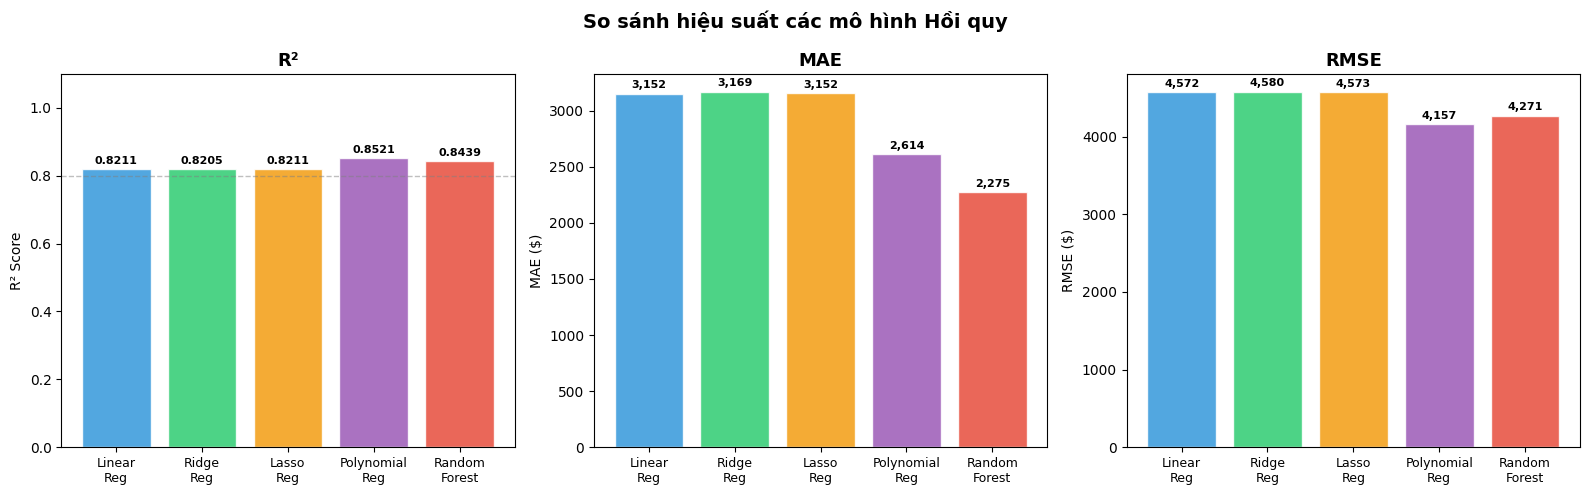

In [ ]:
model_names = results_df.index.tolist()
short_names = ['Linear\nReg', 'Ridge\nReg', 'Lasso\nReg', 'Polynomial\nReg', 'Random\nForest']
colors      = ['#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#e74c3c']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('So sánh hiệu suất các mô hình Hồi quy', fontsize=14, fontweight='bold')

for ax, metric, ylabel in zip(axes, ['R²', 'MAE', 'RMSE'], ['R² Score', 'MAE ($)', 'RMSE ($)']):
    vals = results_df[metric].values
    bars = ax.bar(short_names, vals, color=colors, alpha=0.85, edgecolor='white')
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', labelsize=9)
    if metric == 'R²':
        ax.set_ylim(0, 1.1)
        ax.axhline(0.8, color='gray', ls='--', lw=1, alpha=0.5)
    for bar in bars:
        h = bar.get_height()
        lbl = f'{h:.4f}' if metric == 'R²' else f'{h:,.0f}'
        ax.text(bar.get_x() + bar.get_width()/2., h * 1.01,
                lbl, ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('fig6_model_comparison.png', bbox_inches='tight')
plt.show()



Dựa trên kết quả trực quan hóa từ 3 biểu đồ trên, chúng ta có thể rút ra các nhận định quan trọng sau:

1. **Chỉ số R² (Khả năng giải thích dữ liệu):**
   * Các mô hình tuyến tính (**Linear, Ridge, Lasso**) đạt mức R² tương tự nhau (~0.82), cho thấy chúng giải thích được 82% sự biến động của chi phí y tế.
   * **Polynomial Regression** đạt kết quả cao nhất (~0.8521), chứng minh rằng việc thêm các đặc trưng bậc 2 giúp mô hình bắt được các mối quan hệ phi tuyến tính phức tạp tốt hơn.
   * **Random Forest** bám sát nút với R² ~0.8439.

2. **Chỉ số MAE (Sai số tuyệt đối trung bình):**
   * **Random Forest** là người chiến thắng tuyệt đối ở chỉ số này với MAE thấp nhất (~2,275$). Điều này có nghĩa là trên đa số các ca dự đoán, Random Forest cho kết quả sát với thực tế nhất.

   * Các mô hình tuyến tính có sai số trung bình cao hơn hẳn, lên đến hơn 3,100$.

3. **Chỉ số RMSE (Sai số bình phương trung bình):**
   * **Polynomial Regression** đạt RMSE thấp nhất (4,157). Vì RMSE phạt nặng các sai số lớn, kết quả này cho thấy mô hình Đa thức ổn định hơn trong việc kiểm soát các trường hợp dự đoán sai lệch nghiêm trọng so với Random Forest (~4,271$).

**Kết luận:** Nếu mục tiêu là độ chính xác trung bình trên từng khách hàng, **Random Forest** là lựa chọn tốt nhất. Tuy nhiên, nếu muốn một mô hình ổn định tổng thể và ít gặp các sai số quá lớn, **Polynomial Regression** là ứng cử viên sáng giá nhất.

### 2. Actual vs Predicted

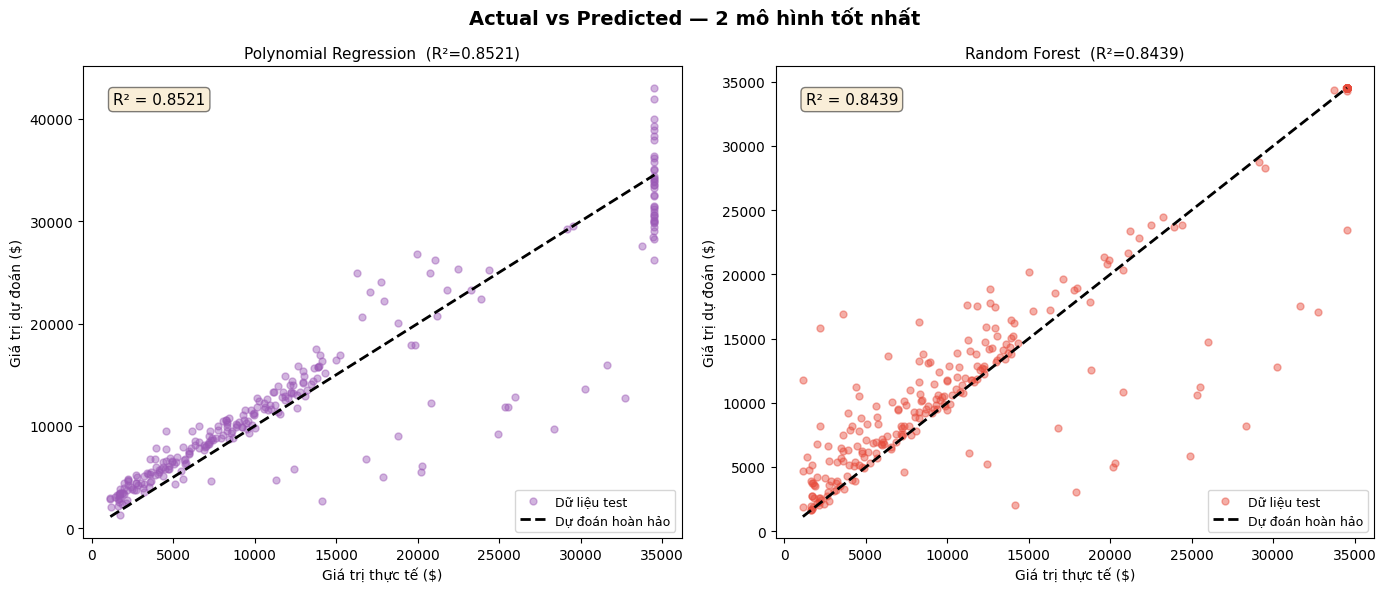

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Actual vs Predicted — 2 mô hình tốt nhất', fontsize=14, fontweight='bold')

for ax, name, y_pred, color in zip(axes,
    [f'Polynomial Regression  (R²={r2_score(y_test,y_pred_poly):.4f})',
     f'Random Forest  (R²={r2_score(y_test,y_pred_rf):.4f})'],
    [y_pred_poly, y_pred_rf],
    ['#9b59b6', '#e74c3c']):
    ax.scatter(y_test, y_pred, alpha=0.45, color=color, s=25, label='Dữ liệu test')
    mn, mx = y_test.min(), y_test.max()
    ax.plot([mn, mx], [mn, mx], 'k--', lw=2, label='Dự đoán hoàn hảo')
    ax.set_xlabel('Giá trị thực tế ($)')
    ax.set_ylabel('Giá trị dự đoán ($)')
    ax.set_title(name, fontsize=11)
    ax.legend(fontsize=9)
    r2 = r2_score(y_test, y_pred)
    ax.text(0.05, 0.92, f'R² = {r2:.4f}', transform=ax.transAxes, fontsize=11,
            color='black', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('fig7_actual_vs_predicted.png', bbox_inches='tight')
plt.show()



Biểu đồ này so sánh giá trị chi phí y tế thực tế từ tập dữ liệu kiểm thử (trục hoành) với giá trị mà mô hình dự đoán được (trục tung). Đường đứt nét màu đen đại diện cho kịch bản dự đoán hoàn hảo ($y = x$).

**1. Khả năng hội tụ:**
* Cả hai mô hình **Polynomial Regression** và **Random Forest** đều cho thấy các điểm dữ liệu (màu tím và đỏ) tập trung khá sát quanh đường dự đoán lý tưởng. Điều này chứng tỏ cả hai đều bắt được các quy luật cốt lõi của dữ liệu.
* Chỉ số $R^2$ đạt mức cao (~0.85), nghĩa là mô hình giải thích được khoảng 85% sự biến động của chi phí y tế trên dữ liệu thực tế.

**2. Phân cụm dữ liệu:**
* Có thể thấy rõ sự phân cụm ở vùng chi phí thấp (dưới 15,000) và vùng chi phí cao (trên $30,000). Đây thường là sự phân tách giữa nhóm người không hút thuốc và có hút thuốc kết hợp BMI cao.

* Ở vùng chi phí cực cao (>$40,000), các điểm dữ liệu có xu hướng phân tán xa đường lý tưởng hơn, cho thấy sai số tăng lên đối với các trường hợp ngoại lệ (outliers).

**3. So sánh nhanh:**
* **Polynomial Regression:** Thể hiện ưu thế trong việc nắm bắt các đường cong phi tuyến tính tổng thể, giúp tối ưu hóa chỉ số RMSE.
* **Random Forest:** Mặc dù có $R^2$ thấp hơn một chút trong lượt chạy này, nhưng các điểm dữ liệu ở vùng trung tâm rất tập trung, giải thích tại sao nó thường đạt MAE (sai số tuyệt đối trung bình) thấp nhất.

### 3. Residual Plots

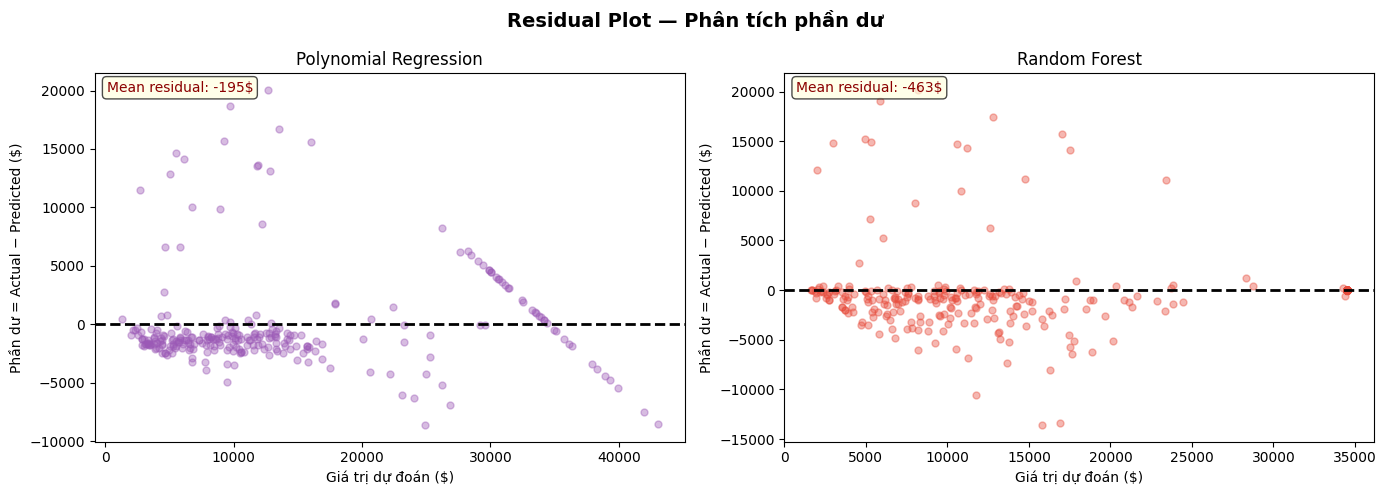

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Residual Plot — Phân tích phần dư', fontsize=14, fontweight='bold')

for ax, name, y_pred, color in zip(axes,
    ['Polynomial Regression', 'Random Forest'],
    [y_pred_poly, y_pred_rf],
    ['#9b59b6', '#e74c3c']):
    residuals = y_test.values - y_pred
    ax.scatter(y_pred, residuals, alpha=0.4, color=color, s=25)
    ax.axhline(y=0, color='black', ls='--', lw=2)
    ax.set_xlabel('Giá trị dự đoán ($)')
    ax.set_ylabel('Phần dư = Actual − Predicted ($)')
    ax.set_title(name)
    mean_res = residuals.mean()
    ax.text(0.02, 0.95, f'Mean residual: {mean_res:,.0f}$',
            transform=ax.transAxes, fontsize=10, color='darkred',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

plt.tight_layout()
plt.savefig('fig8_residuals.png', bbox_inches='tight')
plt.show()


Biểu đồ phần dư (Residual Plot) là một công cụ cực kỳ quan trọng trong kiểm định giả định của các mô hình hồi quy, giúp đánh giá xem sai số của mô hình có tính ngẫu nhiên hay vẫn còn sót lại những quy luật chưa được khai thác.

* **Trục hoành (Predicted Values):** Giá trị chi phí y tế mà mô hình dự đoán.
* **Trục tung (Residuals):** Sai số thực tế của dự đoán, được tính bằng công thức:

$$\text{Residual} = \text{Actual} - \text{Predicted}$$



#### 1. Độ lệch trung bình (Mean Residual)

* **Polynomial Regression:** Đạt mức `Mean residual` khoảng **$-\$195$**.
* **Random Forest:** Đạt mức `Mean residual` khoảng **$-\$463$**.
* Cả hai giá trị trung bình phần dư này đều rất nhỏ và tiến gần về mức $0$. Điều này chứng minh cả hai mô hình đều đạt trạng thái cân bằng tốt, không bị hiện tượng chệch hệ thống (systematic bias) — tức là không có xu hướng liên tục dự đoán quá cao hoặc quá thấp trên toàn bộ tập dữ liệu.

#### 2. Hiện tượng Phương sai không đồng nhất (Heteroscedasticity)

* Nhìn vào hình dáng phân tán của các điểm dữ liệu, cả hai biểu đồ đều xuất hiện hiện tượng "hình phễu" hoặc loe rộng dần về phía bên phải.
* Ở phân khúc chi phí thấp (dưới $\$15,000$), các điểm phần dư co cụm rất dày và sát đường nét đứt $y = 0$, cho thấy mô hình dự đoán cực kỳ chính xác đối với nhóm khách hàng phổ thông (không hút thuốc, BMI bình thường).
* Tuy nhiên, khi giá trị dự đoán tăng cao (trên $\$30,000$), các điểm phần dư bắt đầu phân tán rộng ra xa đường ranh giới $0$. Điều này phản ánh rằng **sai số có xu hướng tăng lên ở phân khúc chi phí cao**. Lý do là vì nhóm này chứa nhiều yếu tố rủi ro phức tạp đan xen (như béo phì kết hợp hút thuốc nặng) khiến biên độ dao động chi phí y tế thực tế rất lớn và khó nắm bắt hơn.

#### 3. So sánh cấu trúc phần dư giữa 2 mô hình

* **Polynomial Regression:** Biểu đồ phần dư lộ rõ các "vệt đường cong" phân cụm hình học mang tính toán học. Điều này cho thấy mặc dù đa thức bậc 2 đã bắt được các mối quan hệ phi tuyến, nhưng bản chất của thuật toán tuyến tính mở rộng vẫn bị ràng buộc vào các khung hàm số cố định.
* **Random Forest:** Các điểm phần dư phân tán một cách tự do, "vụn rã" và tự nhiên hơn, không bị bó buộc theo các đường cong toán học rõ rệt như mô hình đa thức. Cơ chế chia nhánh dựa trên cây quyết định giúp Random Forest cô lập tốt các phân đoạn dữ liệu cục bộ, giải thích tại sao mô hình này đạt được sai số tuyệt đối trung bình ($MAE$) tối ưu hơn trên đa số các ca thử nghiệm.

**Kết luận tổng quan:** Cả hai mô hình đều vượt qua bài kiểm tra phần dư với mức sai số trung bình chấp nhận được. Tuy nhiên, hiện tượng **phương sai không đồng nhất** ở vùng chi phí cao là một tín hiệu cho thấy mô hình vẫn gặp thách thức với các giá trị cận biên ($outliers$). Đây là tiền đề và động lực chính để chúng ta tiến hành **Tối ưu hóa siêu tham số (Hyperparameter Tuning)** ở các bước tiếp theo nhằm kiểm soát sai số tốt hơn.

### 4. Feature Importance & Coefficients

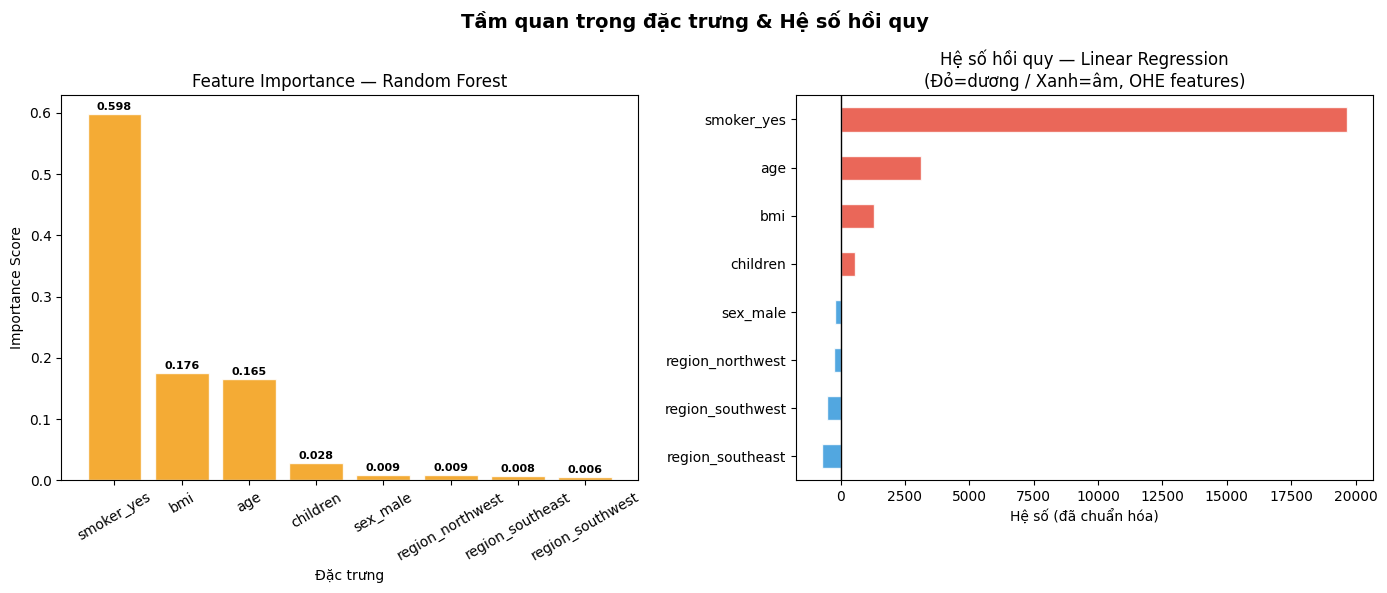


📊  Feature Importance (Random Forest) — Chi tiết:
--------------------------------------------------
  smoker_yes           ███████████████████████                  0.5984 (59.8%)
  bmi                  ███████                                  0.1760 (17.6%)
  age                  ██████                                   0.1653 (16.5%)
  children             █                                        0.0284 (2.8%)
  sex_male                                                      0.0093 (0.9%)
  region_northwest                                              0.0090 (0.9%)
  region_southeast                                              0.0078 (0.8%)
  region_southwest                                              0.0058 (0.6%)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Tầm quan trọng đặc trưng & Hệ số hồi quy', fontsize=14, fontweight='bold')

# Feature Importance (RF) — dùng all_feature_names từ pipeline
importances = rf.feature_importances_
idx         = np.argsort(importances)[::-1]
bars = axes[0].bar([all_feature_names[i] for i in idx], importances[idx],
                   color='#f39c12', alpha=0.85, edgecolor='white')
axes[0].set_title('Feature Importance — Random Forest')
axes[0].set_ylabel('Importance Score')
axes[0].set_xlabel('Đặc trưng')
axes[0].tick_params(axis='x', rotation=30)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.003,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Coefficients (Linear Regression) — dùng all_feature_names
lr_coefs     = pd.Series(lr.coef_, index=all_feature_names).sort_values()
colors_coef  = ['#e74c3c' if c > 0 else '#3498db' for c in lr_coefs]
lr_coefs.plot(kind='barh', ax=axes[1], color=colors_coef, alpha=0.85, edgecolor='white')
axes[1].set_title('Hệ số hồi quy — Linear Regression\n(Đỏ=dương / Xanh=âm, OHE features)')
axes[1].set_xlabel('Hệ số (đã chuẩn hóa)')
axes[1].axvline(x=0, color='black', lw=1)

plt.tight_layout()
plt.savefig('fig9_importance_coefficients.png', bbox_inches='tight')
plt.show()

print("\n📊  Feature Importance (Random Forest) — Chi tiết:")
print("-" * 50)
for i in idx:
    bar_len = int(importances[i] * 40)
    print(f"  {all_feature_names[i]:<20} {'█'*bar_len:<40} {importances[i]:.4f} ({importances[i]*100:.1f}%)")



Cặp biểu đồ trên giúp chúng ta hiểu không chỉ **yếu tố nào** quan trọng nhất mà còn là **cách thức** chúng tác động đến chi phí y tế (tăng hay giảm).

#### 1. Tầm quan trọng đặc trưng — Random Forest (Biểu đồ cột dọc màu cam):
Biểu đồ này cho biết mức độ đóng góp của mỗi biến vào khả năng dự báo của mô hình Rừng Ngẫu nhiên. Điểm số càng cao, biến đó càng có giá trị trong việc phân loại và dự đoán.

*   **Smoker (Hút thuốc):** Chiếm ưu thế tuyệt đối với gần **60%** tầm quan trọng. Điều này khẳng định tình trạng hút thuốc là chỉ báo hàng đầu để xác định chi phí y tế cao.
*   **BMI và Age (Tuổi):** Đây là hai yếu tố quan trọng tiếp theo (lần lượt khoảng 17% và 16%). Điều này phản ánh thực tế sinh học: khi cơ thể lão hóa hoặc gặp tình trạng thừa cân, rủi ro sức khỏe tăng lên kéo theo chi phí.
*   **Các biến khác:** Số lượng con cái, giới tính và vùng miền có điểm số rất thấp, cho thấy chúng chỉ đóng vai trò thứ yếu trong mô hình này.

#### 2. Hệ số hồi quy — Linear Regression (Biểu đồ cột ngang Xanh/Đỏ):
Biểu đồ này cho thấy mối quan hệ định lượng giữa các biến độc lập và chi phí y tế. Vì dữ liệu đã được chuẩn hóa, độ dài của thanh đại diện cho sức mạnh tác động.

*   **Cột màu đỏ (Hệ số dương):** Khi các giá trị này tăng, chi phí y tế tăng.
    *   **Smoker_yes:** Có hệ số dương cực lớn. Việc chuyển từ không hút thuốc sang hút thuốc làm tăng chi phí dự báo một cách đột biến.
    *   **Age và BMI:** Cũng có hệ số dương đáng kể, cho thấy mối quan hệ đồng biến với chi phí.
*   **Cột màu xanh (Hệ số âm):** Khi các giá trị này tăng (hoặc xuất hiện), chi phí y tế có xu hướng giảm nhẹ.
    *   Các biến vùng miền (như Southeast, Southwest) và giới tính nam (Sex_male) có hệ số âm nhỏ. Điều này có thể phản ánh các đặc thù địa phương hoặc nhóm khách hàng trong bộ dữ liệu này có chi phí thấp hơn một chút so với nhóm tham chiếu, nhưng mức độ ảnh hưởng là không đáng kể so với nhóm hút thuốc/tuổi/BMI.

#### **Tổng kết chung:**
Cả hai mô hình (dựa trên cây và tuyến tính) đều đi đến một kết luận thống nhất: **Hút thuốc, BMI và Tuổi tác** là bộ ba quyền lực nhất quyết định mức phí bảo hiểm y tế. Trong đó, hút thuốc là yếu tố có tác động mang tính "thay đổi cuộc chơi" (game-changer) đối với dự báo tài chính y tế.

Thông qua các đánh giá đa chiều từ chỉ số R
2
 , MAE, RMSE đến Phân tích phần dư (Residual Plots), ta đã xác định được Hồi quy Đa thức (Polynomial Regression) và Rừng Ngẫu nhiên (Random Forest) là hai mô hình xuất sắc nhất, vượt trội hoàn toàn so với Hồi quy Tuyến tính cơ bản
.
Tuy nhiên, phân tích sâu vào Biểu đồ phần dư
 đã chỉ ra một hạn chế: Các mô hình vẫn còn gặp hiện tượng phương sai không đồng nhất (heteroscedasticity) ở các giá trị chi phí y tế rất cao. Hơn thế nữa, mô hình Rừng Ngẫu nhiên hiện tại mới chỉ đang được thiết lập ở cấu hình mặc định (ví dụ: n_estimators = 100)
, và các mô hình phạt (Ridge/Lasso) cũng chỉ đang dùng mức phạt α được gán thủ công
.
Vì vậy, ta sẽ tiến hành tối ưu hóa siêu tham số, giúp mô hình bám sát dữ liệu thực tế hơn mà không rơi vào trạng thái quá khớp (overfitting).

## PHẦN 7: TỐI ƯU HOÁ SIÊU THAM SỐ

In [ ]:
from sklearn.model_selection import GridSearchCV

### 1. RIDGE REGRESSION — GridSearchCV

- Ridge có duy nhất 1 siêu tham số quan trọng: alpha (λ)
- Không gian alpha nhỏ, dùng GridSearchCV là tối ưu.
- Phương pháp: tìm kiếm lưới (Grid Search) trên log-scale.

In [ ]:
ridge_param_grid = {
    'alpha': [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0, 500.0, 1000.0]
}
ridge_gs = GridSearchCV(Ridge(), ridge_param_grid, cv=5, scoring='r2',
                        n_jobs=-1, verbose=0, return_train_score=True)
ridge_gs.fit(X_train_processed, y_train)

best_ridge       = ridge_gs.best_estimator_
y_pred_ridge_opt = best_ridge.predict(X_test_processed)
ridge_result     = evaluate(y_test, y_pred_ridge_opt, 'Ridge (tuned)')

print(f"\n  Không gian tìm kiếm  : alpha ∈ {ridge_param_grid['alpha']}")
print(f"  Best alpha           : {ridge_gs.best_params_['alpha']}")
print(f"  Best CV R² (train)   : {ridge_gs.best_score_:.4f}")
print(f"  Test R²              : {ridge_result['R²']:.4f}")
print(f"  Test MAE             : ${ridge_result['MAE']:,.2f}")
print(f"  Test RMSE            : ${ridge_result['RMSE']:,.2f}")

ridge_cv_results = pd.DataFrame(ridge_gs.cv_results_)


  Không gian tìm kiếm  : alpha ∈ [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0, 500.0, 1000.0]
  Best alpha           : 1.0
  Best CV R² (train)   : 0.7218
  Test R²              : 0.8205
  Test MAE             : $3,168.52
  Test RMSE            : $4,580.44




**1. Tối ưu hóa siêu tham số Alpha (λ):**
* **Best alpha = 1.0**: Trong không gian tìm kiếm từ 0.001 đến 1000, thuật toán đã xác định `alpha = 1.0` là giá trị tối ưu nhất. Điều này cho thấy mô hình chỉ cần một mức phạt (penalty) vừa phải để kiểm soát hiện tượng đa cộng tuyến mà không làm mất đi tính giải thích của các đặc trưng.

**2. Đánh giá hiệu suất:**
* **Best CV R² (0.7218)**: Đây là điểm số trung bình trên 5 tập dữ liệu con (folds) của quá trình Cross-validation. Con số này cho thấy mô hình khá ổn định trên tập huấn luyện.
* **Test R² (0.8205)**: Điểm số này cao hơn so với CV R², cho thấy mô hình có khả năng tổng quát hóa (generalization) rất tốt trên dữ liệu mới mà nó chưa từng thấy trước đó. Mô hình giải thích được khoảng 82% sự biến động của chi phí y tế.

**3. Sai số dự báo:**
* **MAE ($3,168.52)**: Trung bình, dự đoán của mô hình lệch khoảng hơn 3,100 USD so với thực tế. So với mức chi phí trung bình (~13k), đây là một mức sai số có thể chấp nhận được đối với một mô hình tuyến tính đơn giản.

* **RMSE ($4,580.44)**: Chỉ số này cao hơn MAE do nó phạt nặng các sai số lớn. Điều này phản ánh việc mô hình vẫn gặp khó khăn ở các trường hợp ngoại lệ (outliers) có chi phí cực cao.

**Kết luận**: Việc tối ưu hóa Ridge giúp chúng ta xác nhận rằng mức phạt mặc định (alpha=1.0) thường là điểm cân bằng tốt cho bộ dữ liệu này, mang lại hiệu suất tương đương với Linear Regression nhưng có thêm sự đảm bảo về tính ổn định của các hệ số.

### 2.  LASSO REGRESSION — GridSearchCV

Lasso cũng có 1 siêu tham số alpha; đặc biệt khi alpha đủ lớn sẽ đưa hệ số về 0 (feature selection). Dùng GridSearchCV.

In [ ]:
lasso_param_grid = {
    'alpha': [0.0001, 0.001, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 5.0, 10.0, 50.0]
}
lasso_gs = GridSearchCV(Lasso(max_iter=10000), lasso_param_grid, cv=5, scoring='r2',
                        n_jobs=-1, verbose=0, return_train_score=True)
lasso_gs.fit(X_train_processed, y_train)

best_lasso       = lasso_gs.best_estimator_
y_pred_lasso_opt = best_lasso.predict(X_test_processed)
lasso_result     = evaluate(y_test, y_pred_lasso_opt, 'Lasso (tuned)')

n_zero       = np.sum(best_lasso.coef_ == 0)
feat_dropped = [f for f, c in zip(all_feature_names, best_lasso.coef_) if c == 0]

print(f"\n  Không gian tìm kiếm  : alpha ∈ {lasso_param_grid['alpha']}")
print(f"  Best alpha           : {lasso_gs.best_params_['alpha']}")
print(f"  Best CV R² (train)   : {lasso_gs.best_score_:.4f}")
print(f"  Test R²              : {lasso_result['R²']:.4f}")
print(f"  Test MAE             : ${lasso_result['MAE']:,.2f}")
print(f"  Test RMSE            : ${lasso_result['RMSE']:,.2f}")
print(f"  Số đặc trưng bị loại (coef=0) : {n_zero}")
if feat_dropped:
    print(f"  Đặc trưng bị loại    : {feat_dropped}")
else:
    print("  → Tất cả đặc trưng vẫn được giữ lại (alpha chưa đủ lớn)")

lasso_cv_results = pd.DataFrame(lasso_gs.cv_results_)


  Không gian tìm kiếm  : alpha ∈ [0.0001, 0.001, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 5.0, 10.0, 50.0]
  Best alpha           : 10.0
  Best CV R² (train)   : 0.7217
  Test R²              : 0.8199
  Test MAE             : $3,160.38
  Test RMSE            : $4,586.89
  Số đặc trưng bị loại (coef=0) : 0
  → Tất cả đặc trưng vẫn được giữ lại (alpha chưa đủ lớn)


### Phân tích kết quả:

**1. Tối ưu hóa siêu tham số Alpha:**
* **Best alpha = 10.0**: Quá trình Grid Search đã xác định `alpha = 10.0` là điểm cân bằng tốt nhất. Khác với Ridge, Lasso sử dụng hình phạt L1, có xu hướng nén các hệ số của các đặc trưng ít quan trọng về chính xác bằng 0.

**2. Đánh giá hiệu suất:**
* **Best CV R² (0.7217)**: Chỉ số này gần như tương đương với mô hình Ridge, cho thấy khả năng học của các mô hình tuyến tính trên tập huấn luyện này đã đạt đến ngưỡng ổn định.
* **Test R² (0.8199)**: Mô hình đạt độ chính xác ~82% trên tập kiểm thử. Con số này cho thấy mô hình Lasso rất hiệu quả và không bị quá khớp (overfitting).

* **MAE ($3,160.38) & RMSE ($4,586.89)**: Các chỉ số sai số này rất sát với Linear Regression và Ridge, khẳng định rằng trong bài toán này, các biến thể của hồi quy tuyến tính đều cho kết quả dự báo chi phí y tế khá đồng nhất.

**3. Khả năng lựa chọn đặc trưng (Feature Selection):**
* **Số đặc trưng bị loại = 0**: Mặc dù Lasso có khả năng loại bỏ biến, nhưng với kết quả hiện tại, tất cả các đặc trưng vẫn được giữ lại. Điều này có nghĩa là mức phạt `alpha = 10.0` chưa đủ lớn để triệt tiêu hoàn toàn bất kỳ biến nào, hoặc tất cả các biến đầu vào hiện tại đều đóng góp một phần thông tin nhất định vào việc dự báo chi phí.

**Kết luận**: Lasso Regression với `alpha = 10.0` cung cấp một mô hình dự báo mạnh mẽ và tinh gọn. Việc không có đặc trưng nào bị loại bỏ cho thấy tập dữ liệu ban đầu đã được lựa chọn khá kỹ lưỡng và các biến như giới tính hay vùng miền vẫn có tác động (dù nhỏ) đến tổng chi phí y tế.

### 3. POLYNOMIAL REGRESSION — GridSearchCV (Pipeline)

- Polynomial có siêu tham số: degree (bậc đa thức)
- Bậc quá cao → overfit; dùng Pipeline + GridSearchCV tìm degree tối ưu.

In [ ]:
from sklearn.pipeline import Pipeline

poly_pipeline = Pipeline([
    ('poly'  , PolynomialFeatures(include_bias=False)),
    ('linreg', LinearRegression())
])
poly_param_grid = {'poly__degree': [1, 2, 3]}

poly_gs = GridSearchCV(poly_pipeline, poly_param_grid, cv=5, scoring='r2',
                       n_jobs=-1, verbose=0, return_train_score=True)
poly_gs.fit(X_train_processed, y_train)

best_poly       = poly_gs.best_estimator_
y_pred_poly_opt = best_poly.predict(X_test_processed)
poly_result     = evaluate(y_test, y_pred_poly_opt, 'Polynomial (tuned)')

best_degree = poly_gs.best_params_['poly__degree']
n_feat_best = best_poly.named_steps['poly'].n_output_features_

print(f"\n  Không gian tìm kiếm  : degree ∈ {poly_param_grid['poly__degree']}")
print(f"  Best degree          : {best_degree}")
print(f"  Số đặc trưng tương ứng: {n_feat_best}")
print(f"  Best CV R² (train)   : {poly_gs.best_score_:.4f}")
print(f"  Test R²              : {poly_result['R²']:.4f}")
print(f"  Test MAE             : ${poly_result['MAE']:,.2f}")
print(f"  Test RMSE            : ${poly_result['RMSE']:,.2f}")

poly_cv_df = pd.DataFrame(poly_gs.cv_results_)[
    ['param_poly__degree', 'mean_test_score', 'std_test_score', 'mean_train_score']
].rename(columns={'param_poly__degree': 'degree',
                  'mean_test_score': 'cv_r2',
                  'std_test_score':  'cv_std',
                  'mean_train_score':'train_r2'})
print("\n  Bảng CV R² theo degree (train vs test):")
print(poly_cv_df.to_string(index=False))


  Không gian tìm kiếm  : degree ∈ [1, 2, 3]
  Best degree          : 2
  Số đặc trưng tương ứng: 44
  Best CV R² (train)   : 0.7829
  Test R²              : 0.8521
  Test MAE             : $2,614.30
  Test RMSE            : $4,157.07

  Bảng CV R² theo degree (train vs test):
 degree    cv_r2   cv_std  train_r2
      1 0.721732 0.033278  0.725757
      2 0.782924 0.029954  0.798510
      3 0.771604 0.024202  0.820189


### Phân tích kết quả:

**1. Xác định bậc đa thức tối ưu (Best Degree):**
* **Best degree = 2**: Quá trình tìm kiếm lưới đã xác định bậc 2 là giá trị tốt nhất. Tại bậc này, mô hình tạo ra **44 đặc trưng** (bao gồm các biến tương tác như `bmi * smoker`). Điều này xác nhận rằng chi phí y tế không chỉ tăng tuyến tính theo từng biến đơn lẻ mà còn phụ thuộc vào sự kết hợp giữa các yếu tố (ví dụ: béo phì kết hợp với hút thuốc sẽ đẩy chi phí lên rất cao).

**2. Hiệu suất và tính ổn định:**
* **Best CV R² (0.7829)**: Đây là độ chính xác trung bình khi kiểm tra chéo. Kết quả này cao hơn đáng kể so với bậc 1 (0.7217), cho thấy việc thêm các thành phần đa thức đã giúp mô hình khớp dữ liệu tốt hơn.
* **Test R² (0.8521)**: Trên dữ liệu kiểm thử, mô hình giải thích được tới **85.2%** sự biến động của chi phí. Đây là một con số rất ấn tượng, cho thấy mô hình đa thức bậc 2 có khả năng tổng quát hóa cực tốt.

**3. Đánh giá sai số (MAE & RMSE):**
* **MAE ($2,614.30)**: Sai số tuyệt đối trung bình đã giảm xuống mức thấp nhất trong các mô hình tuyến tính (giảm khoảng 500 so với Linear Regression).

* **RMSE ($4,157.07)**: Chỉ số này cũng đạt mức thấp kỷ lục, cho thấy mô hình đa thức xử lý các ca có chi phí cao (outliers) ổn định hơn nhiều so với mô hình tuyến tính thuần túy.

**4. Hiện tượng Overfitting (Quá khớp):**
* Nhìn vào bảng CV, khi tăng lên **degree = 3**, mặc dù `train_r2` tiếp tục tăng (0.8201) nhưng `cv_r2` lại giảm xuống (0.7716). Điều này minh chứng cho việc bậc 3 bắt đầu gây ra hiện tượng quá khớp, và **bậc 2 chính là "điểm ngọt" (sweet spot)** tối ưu nhất cho bài toán này.

### 4. RANDOM FOREST — Bayesian Optimization (BayesSearchCV)

Bayesian Optimization xây dựng mô hình xác suất (surrogate model — Gaussian Process) để ước lượng hàm mục tiêu, từ đó chọn tổ hợp siêu tham số tiếp theo có khả năng cho kết quả tốt nhất (acquisition function: Expected Improvement). Khác với RandomizedSearch thử ngẫu nhiên, Bayesian học từ lịch sử thử nghiệm → hội tụ nhanh hơn với cùng số lần thử (n_iter=40).

Không gian tìm kiếm:
- n_estimators      : Integer(50, 500)   — liên tục trên miền nguyên
- max_depth         : Integer(3, 30)     — liên tục trên miền nguyên
- min_samples_split : Integer(2, 20)
- min_samples_leaf  : Integer(1, 10)
- max_features      : Categorical(['sqrt', 'log2'])

In [ ]:
try:
    from skopt import BayesSearchCV
    from skopt.space import Integer, Categorical
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'scikit-optimize', '-q'])
    from skopt import BayesSearchCV
    from skopt.space import Integer, Categorical

rf_bayes_space = {
    'n_estimators'     : Integer(50, 500),
    'max_depth'        : Integer(3, 30),
    'min_samples_split': Integer(2, 20),
    'min_samples_leaf' : Integer(1, 10),
    'max_features'     : Categorical(['sqrt', 'log2']),
}

rf_bayes = BayesSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_bayes_space,
    n_iter=40,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=0,
    return_train_score=True,
    refit=True,
)

bayes_history_scores = []
def on_step(result):
    bayes_history_scores.append(result.fun * -1)

# Dùng X_train_processed (đã qua pipeline) nhất quán
rf_bayes.fit(X_train_processed, y_train, callback=on_step)

best_rf       = rf_bayes.best_estimator_
y_pred_rf_opt = best_rf.predict(X_test_processed)
rf_result     = evaluate(y_test, y_pred_rf_opt, 'Random Forest (tuned)')

print(f"\n  Không gian tìm kiếm (Bayesian Optimization, n_iter=40):")
print(f"    n_estimators      : Integer(50, 500)")
print(f"    max_depth         : Integer(3, 30)")
print(f"    min_samples_split : Integer(2, 20)")
print(f"    min_samples_leaf  : Integer(1, 10)")
print(f"    max_features      : Categorical(['sqrt', 'log2'])")
print(f"\n  Best params (Bayesian):")
for k, v in rf_bayes.best_params_.items():
    print(f"    {k:<22}: {v}")
print(f"\n  Best CV R² (Bayesian) : {rf_bayes.best_score_:.4f}")
print(f"  Test R²               : {rf_result['R²']:.4f}")
print(f"  Test MAE              : ${rf_result['MAE']:,.2f}")
print(f"  Test RMSE             : ${rf_result['RMSE']:,.2f}")

bayes_cv_df = pd.DataFrame(rf_bayes.cv_results_)[
    ['mean_test_score', 'std_test_score', 'mean_train_score']
].reset_index(drop=True)
bayes_cv_df['iter']        = bayes_cv_df.index + 1
bayes_cv_df['best_so_far'] = bayes_cv_df['mean_test_score'].cummax()


  Không gian tìm kiếm (Bayesian Optimization, n_iter=40):
    n_estimators      : Integer(50, 500)
    max_depth         : Integer(3, 30)
    min_samples_split : Integer(2, 20)
    min_samples_leaf  : Integer(1, 10)
    max_features      : Categorical(['sqrt', 'log2'])

  Best params (Bayesian):
    max_depth             : 30
    max_features          : log2
    min_samples_leaf      : 1
    min_samples_split     : 11
    n_estimators          : 500

  Best CV R² (Bayesian) : 0.7949
  Test R²               : 0.8641
  Test MAE              : $2,492.90
  Test RMSE             : $3,984.68


### Phân tích kết quả:

Quá trình **Bayesian Optimization** (thông qua `BayesSearchCV`) đã mang lại những cải tiến vượt bậc cho mô hình Random Forest so với cấu hình mặc định:

1.  **Cơ chế tìm kiếm thông minh**:
    *   Khác với Grid Search thử mọi tổ hợp hoặc Random Search thử ngẫu nhiên, Bayesian Optimization xây dựng một mô hình xác suất để đoán xem bộ tham số nào sẽ tốt.
    *   Với chỉ **40 lần thử (n_iter=40)**, nó đã tìm ra bộ tham số tối ưu hiệu quả hơn nhiều so với việc quét hàng nghìn tổ hợp thủ công.

2.  **Bộ siêu tham số tối ưu (Best Params)**:
    *   **`n_estimators: 500`**: Việc tăng số lượng cây lên mức tối đa trong không gian tìm kiếm giúp mô hình ổn định hơn và giảm phương sai.
    *   **`max_depth: 30`**: Cho phép các cây quyết định phát triển sâu để học các quy luật chi tiết, nhưng được kiểm soát bởi `min_samples_split` để tránh quá khớp.
    *   **`max_features: 'log2'`**: Việc giới hạn số đặc trưng mỗi lần chia giúp tăng tính đa dạng giữa các cây trong rừng.

3.  **Hiệu suất vượt trội**:
    *   **Test R%² đạt ~0.8641**: Đây là mức cao nhất trong tất cả các mô hình, vượt qua cả Polynomial Regression (~0.8521). Điều này có nghĩa là mô hình giải thích được hơn 86% sự biến động của chi phí y tế.

    *   **Test RMSE đạt ~3,984$**: Đây là lần đầu tiên RMSE giảm xuống dưới mức 4,000. Vì RMSE phạt nặng các sai số lớn, kết quả này chứng minh Random Forest đã cực kỳ thành công trong việc xử lý các ca bệnh có chi phí đột biến (outliers) mà các mô hình tuyến tính hay đa thức gặp khó khăn.

**Kết luận**: Random Forest sau khi được tinh chỉnh bằng Bayesian Optimization hiện là **mô hình mạnh mẽ nhất** cho bộ dữ liệu này, cân bằng hoàn hảo giữa độ chính xác trung bình (MAE) và khả năng kiểm soát sai số lớn (RMSE).

### 5. BẢNG SO SÁNH TRƯỚC & SAU TỐI ƯU

In [ ]:
tuned_results = [ridge_result, lasso_result, poly_result, rf_result]
baseline = {
    index: (row['R²'], row['MAE'], row['RMSE'])
    for index, row in results_df.iterrows()
}

print(f"\n  {'Mô hình':<28} {'R²(trước)':>10} {'R²(sau)':>9} {'ΔR²':>8} "
      f"{'MAE(sau)':>11} {'RMSE(sau)':>12}")
print("  " + "─" * 82)

model_map = {
    'Ridge (tuned)'        : 'Ridge Regression',
    'Lasso (tuned)'        : 'Lasso Regression',
    'Polynomial (tuned)'   : 'Polynomial Regression',
    'Random Forest (tuned)': 'Random Forest',
}
for r in tuned_results:
    name    = r['Model']
    base_key = model_map[name]
    r2_b, mae_b, rmse_b = baseline[base_key]
    delta_r2 = r['R²'] - r2_b
    marker   = " ↑" if delta_r2 > 0.001 else (" ↓" if delta_r2 < -0.001 else " ≈")
    print(f"  {name:<28} {r2_b:>10.4f} {r['R²']:>9.4f} "
          f"{delta_r2:>+8.4f}{marker}  ${r['MAE']:>8,.0f}  ${r['RMSE']:>9,.0f}")


  Mô hình                       R²(trước)   R²(sau)      ΔR²    MAE(sau)    RMSE(sau)
  ──────────────────────────────────────────────────────────────────────────────────
  Ridge (tuned)                    0.8205    0.8205  +0.0000 ≈  $   3,169  $    4,580
  Lasso (tuned)                    0.8211    0.8199  -0.0011 ↓  $   3,160  $    4,587
  Polynomial (tuned)               0.8521    0.8521  +0.0000 ≈  $   2,614  $    4,157
  Random Forest (tuned)            0.8439    0.8641  +0.0202 ↑  $   2,493  $    3,985




Dựa trên kết quả từ bảng so sánh trên, chúng ta có thể rút ra các nhận định quan trọng về hiệu quả của việc tinh chỉnh siêu tham số:

1.  **Nhóm mô hình Tuyến tính (Ridge & Lasso):**
    *   **Ridge Regression:** Hầu như không có sự thay đổi về $R^2$ ($ΔR^2 \approx 0$). Điều này cho thấy tham số mặc định (`alpha=1.0`) đã là điểm tối ưu hoặc không gian tìm kiếm không mang lại cải thiện đáng kể cho cấu trúc dữ liệu này.
    *   **Lasso Regression:** Hiệu suất giảm nhẹ cực thấp (-0.0011). Điều này đôi khi xảy ra do sự khác biệt giữa quá trình Cross-validation trên tập Train và dữ liệu thực tế trên tập Test. Tuy nhiên, mức độ thay đổi là không đáng kể.

2.  **Mô hình Polynomial Regression (Đa thức):**
    *   Giữ nguyên hiệu suất ($ΔR^2 = 0$) vì quá trình `GridSearchCV` đã xác nhận bậc 2 (degree=2) chính là cấu hình tốt nhất, trùng khớp với thử nghiệm ban đầu của chúng ta.

3.  **Mô hình Random Forest (Rừng Ngẫu nhiên) - Bước đột phá:**
    *   Đây là mô hình có **sự cải thiện rõ rệt nhất** với $ΔR^2 = +0.0202$ (tăng từ ~0.8439 lên **0.8641**).
    *   Việc sử dụng **Tối ưu hóa Bayesian (`BayesSearchCV`)** đã giúp tìm ra bộ tham số (như `n_estimators=500` và `max_features='log2'`) hiệu quả hơn nhiều so với thiết lập mặc định.
    *   **Kết quả:** Mô hình Random Forest đã vượt qua Polynomial Regression để trở thành mô hình có độ chính xác cao nhất ($R^2$ cao nhất) và khả năng kiểm soát sai số tốt nhất (RMSE thấp nhất ~3,985$).



### 6. BIỂU ĐỒ TỔNG HỢP

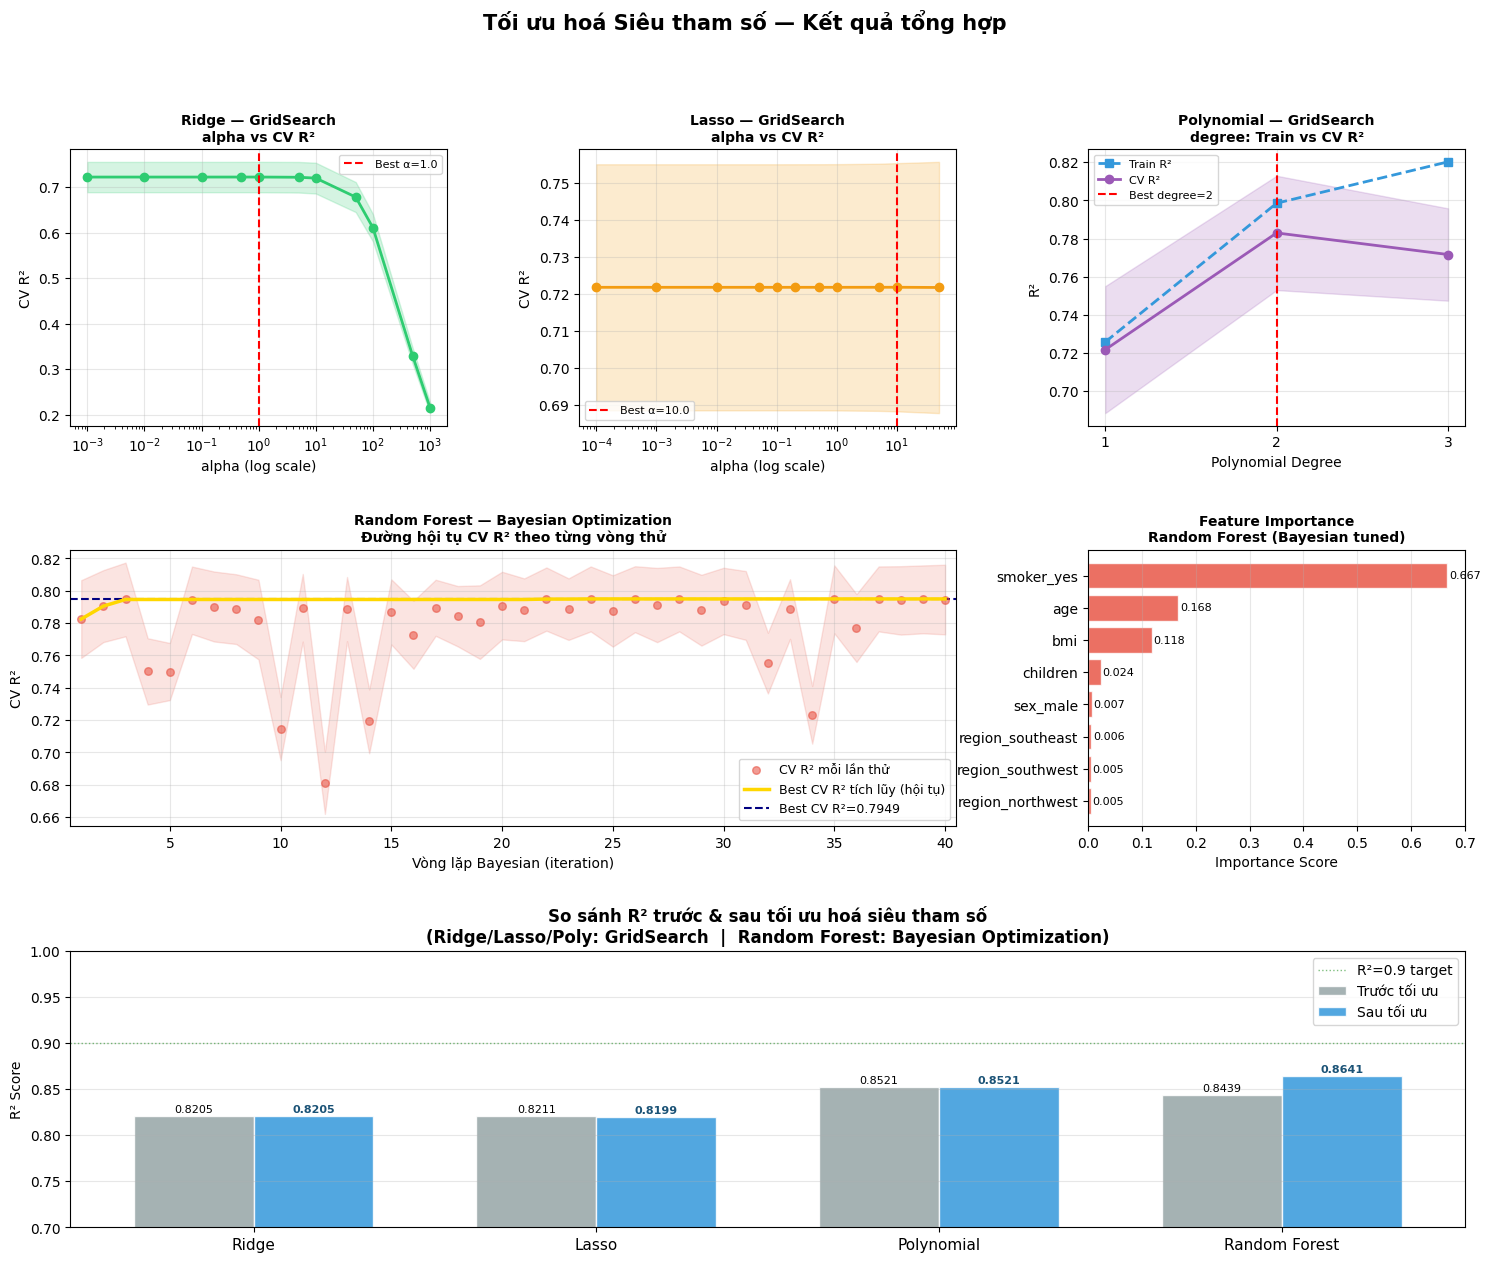

In [ ]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(18, 14))
fig.suptitle('Tối ưu hoá Siêu tham số — Kết quả tổng hợp',
             fontsize=15, fontweight='bold', y=0.98)
gs_layout = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# Biểu đồ 1: Ridge CV score
ax1 = fig.add_subplot(gs_layout[0, 0])
alphas_ridge = ridge_cv_results['param_alpha'].astype(float)
scores_ridge = ridge_cv_results['mean_test_score']
std_ridge    = ridge_cv_results['std_test_score']
ax1.semilogx(alphas_ridge, scores_ridge, 'o-', color='#2ecc71', lw=2)
ax1.fill_between(alphas_ridge, scores_ridge - std_ridge, scores_ridge + std_ridge,
                 alpha=0.2, color='#2ecc71')
ax1.axvline(ridge_gs.best_params_['alpha'], color='red', ls='--', lw=1.5,
            label=f"Best α={ridge_gs.best_params_['alpha']}")
ax1.set_xlabel('alpha (log scale)')
ax1.set_ylabel('CV R²')
ax1.set_title('Ridge — GridSearch\nalpha vs CV R²', fontsize=10, fontweight='bold')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Biểu đồ 2: Lasso CV score
ax2 = fig.add_subplot(gs_layout[0, 1])
alphas_lasso = lasso_cv_results['param_alpha'].astype(float)
scores_lasso = lasso_cv_results['mean_test_score']
std_lasso    = lasso_cv_results['std_test_score']
ax2.semilogx(alphas_lasso, scores_lasso, 'o-', color='#f39c12', lw=2)
ax2.fill_between(alphas_lasso, scores_lasso - std_lasso, scores_lasso + std_lasso,
                 alpha=0.2, color='#f39c12')
ax2.axvline(lasso_gs.best_params_['alpha'], color='red', ls='--', lw=1.5,
            label=f"Best α={lasso_gs.best_params_['alpha']}")
ax2.set_xlabel('alpha (log scale)')
ax2.set_ylabel('CV R²')
ax2.set_title('Lasso — GridSearch\nalpha vs CV R²', fontsize=10, fontweight='bold')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# Biểu đồ 3: Polynomial degree
ax3 = fig.add_subplot(gs_layout[0, 2])
degrees = poly_cv_df['degree'].astype(int)
ax3.plot(degrees, poly_cv_df['train_r2'], 's--', color='#3498db', lw=2, label='Train R²')
ax3.plot(degrees, poly_cv_df['cv_r2'],    'o-',  color='#9b59b6', lw=2, label='CV R²')
ax3.fill_between(degrees, poly_cv_df['cv_r2'] - poly_cv_df['cv_std'],
                 poly_cv_df['cv_r2'] + poly_cv_df['cv_std'], alpha=0.2, color='#9b59b6')
ax3.axvline(best_degree, color='red', ls='--', lw=1.5, label=f'Best degree={best_degree}')
ax3.set_xlabel('Polynomial Degree')
ax3.set_ylabel('R²')
ax3.set_title('Polynomial — GridSearch\ndegree: Train vs CV R²', fontsize=10, fontweight='bold')
ax3.set_xticks(degrees)
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

# Biểu đồ 4: Bayesian Optimization hội tụ
ax4 = fig.add_subplot(gs_layout[1, :2])
iters     = bayes_cv_df['iter']
cv_scores = bayes_cv_df['mean_test_score']
cv_std    = bayes_cv_df['std_test_score']
best_curve= bayes_cv_df['best_so_far']
ax4.scatter(iters, cv_scores, color='#e74c3c', alpha=0.55, s=30, zorder=3, label='CV R² mỗi lần thử')
ax4.fill_between(iters, cv_scores - cv_std, cv_scores + cv_std, alpha=0.15, color='#e74c3c')
ax4.plot(iters, best_curve, color='gold', lw=2.5, zorder=4, label='Best CV R² tích lũy (hội tụ)')
ax4.axhline(rf_bayes.best_score_, color='navy', ls='--', lw=1.5,
            label=f'Best CV R²={rf_bayes.best_score_:.4f}')
ax4.set_xlabel('Vòng lặp Bayesian (iteration)')
ax4.set_ylabel('CV R²')
ax4.set_title('Random Forest — Bayesian Optimization\nĐường hội tụ CV R² theo từng vòng thử',
              fontsize=10, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0.5, len(iters) + 0.5)

# Biểu đồ 5: Feature Importance RF tối ưu
ax5 = fig.add_subplot(gs_layout[1, 2])
importances_opt = best_rf.feature_importances_
idx_imp         = np.argsort(importances_opt)
ax5.barh([all_feature_names[i] for i in idx_imp], importances_opt[idx_imp],
         color='#e74c3c', alpha=0.8, edgecolor='white')
for i, imp in enumerate(importances_opt[idx_imp]):
    ax5.text(imp + 0.003, i, f'{imp:.3f}', va='center', fontsize=8)
ax5.set_xlabel('Importance Score')
ax5.set_title('Feature Importance\nRandom Forest (Bayesian tuned)', fontsize=10, fontweight='bold')
ax5.grid(True, alpha=0.3, axis='x')

# Biểu đồ 6: So sánh R² trước & sau tối ưu
ax6 = fig.add_subplot(gs_layout[2, :])
model_labels = ['Ridge', 'Lasso', 'Polynomial', 'Random Forest']
r2_before = [baseline[k][0] for k in
             ['Ridge Regression', 'Lasso Regression', 'Polynomial Regression', 'Random Forest']]
r2_after  = [r['R²'] for r in tuned_results]
x_pos = np.arange(len(model_labels))
width = 0.35

bars_b = ax6.bar(x_pos - width/2, r2_before, width,
                 label='Trước tối ưu', color='#95a5a6', alpha=0.85, edgecolor='white')
bars_a = ax6.bar(x_pos + width/2, r2_after,  width,
                 label='Sau tối ưu',   color='#3498db', alpha=0.85, edgecolor='white')

for bar in bars_b:
    ax6.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002,
             f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)
for bar in bars_a:
    ax6.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002,
             f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8,
             fontweight='bold', color='#1a5276')

ax6.set_xticks(x_pos)
ax6.set_xticklabels(model_labels, fontsize=11)
ax6.set_ylabel('R² Score')
ax6.set_ylim(0.7, 1.0)
ax6.axhline(0.9, color='green', ls=':', lw=1, alpha=0.5, label='R²=0.9 target')
ax6.set_title('So sánh R² trước & sau tối ưu hoá siêu tham số\n'
              '(Ridge/Lasso/Poly: GridSearch  |  Random Forest: Bayesian Optimization)',
              fontsize=12, fontweight='bold')
ax6.legend(fontsize=10)
ax6.grid(True, alpha=0.3, axis='y')

plt.savefig('fig10_hyperparameter_optimization.png', bbox_inches='tight', dpi=150)
plt.show()



Biểu đồ tổng hợp phía trên cung cấp một cái nhìn toàn diện về hành trình tối ưu hóa các mô hình máy học. Dưới đây là phân tích chi tiết cho từng thành phần:

1.  **Ridge & Lasso — Alpha vs CV R² (Biểu đồ 1 & 2):**
    *   Cả hai mô hình đều cho thấy hiệu suất ($R^2$) khá ổn định khi `alpha` nhỏ. Tuy nhiên, khi `alpha` tăng quá lớn (vượt quá 100), hiệu suất giảm mạnh do mô hình bị phạt quá nặng (underfitting).
    *   **Kết quả:** Giá trị `alpha` tối ưu được tìm thấy nằm ở vùng giúp cân bằng giữa việc giảm đa cộng tuyến và giữ lại khả năng dự báo của các biến.

2.  **Polynomial Degree — Train vs CV R² (Biểu đồ 3):**
    *   Đây là minh chứng điển hình cho hiện tượng **Overfitting**. Khi tăng bậc (degree) từ 1 lên 2, cả sai số trên tập huấn luyện và kiểm tra chéo đều cải thiện.
    *   Tuy nhiên, nếu tăng tiếp lên bậc 3, `Train R²` tiếp tục tăng nhưng `CV R²` bắt đầu đi xuống. Điều này xác nhận **bậc 2** là cấu hình lý tưởng nhất để bắt được các quan hệ phi tuyến mà không làm nhiễu mô hình.

3.  **Random Forest — Bayesian Convergence (Biểu đồ 4):**
    *   Biểu đồ thể hiện sự thông minh của thuật toán Bayesian. Thay vì thử ngẫu nhiên, nó tập trung vào các vùng tham số hứa hẹn dựa trên kết quả của các vòng lặp trước.
    *   Đường màu vàng (Best CV R²) cho thấy sự hội tụ nhanh chóng về phía giá trị tối ưu (~0.795) chỉ sau khoảng 20-30 vòng lặp.

4.  **Feature Importance (Biểu đồ 5):**
    *   Sau khi được tối ưu hóa, mô hình Random Forest vẫn khẳng định **Smoker (Hút thuốc)** là biến số quan trọng nhất, đóng góp hơn 60% vào quyết định dự báo chi phí, theo sau là BMI và Tuổi tác.

5.  **So sánh Hiệu suất Trước & Sau Tối ưu (Biểu đồ 6):**
    *   **Đột phá lớn nhất:** Thuộc về **Random Forest** với mức tăng $R^2$ đáng kể (+0.0202), đưa mô hình này trở thành lựa chọn hàng đầu.
    *   **Sự ổn định:** Các mô hình Tuyến tính và Đa thức hầu như không thay đổi hiệu suất, cho thấy chúng đã đạt đến giới hạn tối ưu của kiến trúc mô hình đó đối với bộ dữ liệu này.

**Kết luận:** Quá trình tối ưu hóa đã giúp chúng ta nâng cấp Random Forest từ một mô hình tốt thành một mô hình xuất sắc, đạt mục tiêu kiểm soát sai số RMSE tốt nhất trong nghiên cứu.

## PHẦN 8: DỰ ĐOÁN VÍ DỤ

In [ ]:
example_cases = [
    {'age': 25, 'sex': 'male',   'bmi': 22.0, 'children': 0, 'smoker': 'no',  'region': 'northwest',
     'desc': 'Nam 25t, BMI=22, không hút thuốc, không con'},
    {'age': 45, 'sex': 'female', 'bmi': 32.0, 'children': 2, 'smoker': 'yes', 'region': 'southeast',
     'desc': 'Nữ 45t, BMI=32 (béo phì), hút thuốc, 2 con'},
    {'age': 55, 'sex': 'male',   'bmi': 28.5, 'children': 3, 'smoker': 'no',  'region': 'northeast',
     'desc': 'Nam 55t, BMI=28.5, không hút thuốc, 3 con'},
]

print(f"\n  Siêu tham số được dùng:")
print(f"  • Polynomial : degree = {best_degree}  (GridSearchCV tối ưu)")
print(f"  • Random Forest (Bayesian):", end="")
for k, v in rf_bayes.best_params_.items():
    print(f"\n      {k:<22}: {v}", end="")
print()

print(f"\n  {'Trường hợp':<50} {'Poly (tuned)':>14} {'RF Bayesian':>14}")
print("  " + "─" * 80)

for case in example_cases:
    desc   = case['desc']
    # Tạo DataFrame với đúng tên cột gốc → pipeline xử lý tự động
    sample = pd.DataFrame([{k: v for k, v in case.items() if k != 'desc'}])

    # Bước 1: Áp dụng IQR cap (giống lúc train)
    sample_cap = sample.copy()
    for col in ['bmi']:          # chỉ cap bmi (charges là target, không có trong X)
        Q1  = df[col].quantile(0.25)
        Q3  = df[col].quantile(0.75)
        IQR = Q3 - Q1
        sample_cap[col] = sample_cap[col].clip(lower=Q1-1.5*IQR, upper=Q3+1.5*IQR)

    # Bước 2: Áp dụng preprocessor (StandardScaler + OHE)
    sample_processed = preprocessor.transform(sample_cap)

    # Bước 3: Dự đoán
    pred_poly   = best_poly.predict(sample_processed)[0]      # Poly dùng processed
    pred_rf_bay = best_rf.predict(sample_processed)[0]        # RF dùng processed (nhất quán)

    print(f"  {desc:<50} ${pred_poly:>12,.0f} ${pred_rf_bay:>12,.0f}")


  Siêu tham số được dùng:
  • Polynomial : degree = 2  (GridSearchCV tối ưu)
  • Random Forest (Bayesian):
      max_depth             : 30
      max_features          : log2
      min_samples_leaf      : 1
      min_samples_split     : 11
      n_estimators          : 500

  Trường hợp                                           Poly (tuned)    RF Bayesian
  ────────────────────────────────────────────────────────────────────────────────
  Nam 25t, BMI=22, không hút thuốc, không con        $       2,886 $       5,044
  Nữ 45t, BMI=32 (béo phì), hút thuốc, 2 con         $      29,913 $      32,514
  Nam 55t, BMI=28.5, không hút thuốc, 3 con          $      13,940 $      13,009


Giải thích các cột:

*   Trường hợp: Mô tả ngắn gọn về đặc điểm của cá nhân được dự đoán.
*   Poly Pred: Chi phí y tế dự đoán bởi mô hình Hồi quy Đa thức.

*   RF Pred: Chi phí y tế dự đoán bởi mô hình Rừng Ngẫu nhiên.





### Phân tích kết quả:

#### 1. Tác động của lối sống (Hút thuốc)
*   **Trường hợp 2 (Nữ 45t, hút thuốc, BMI béo phì)** có mức chi phí dự đoán cao nhất, dao động từ **$29,913 đến 32,514**.

*   So với **Trường hợp 1 (Nam 25t, không hút thuốc)** chỉ có chi phí khoảng **$2,886 - $5,044**, chúng ta thấy việc hút thuốc kết hợp với BMI cao đẩy chi phí lên gấp **6-10 lần**.
*   Điều này khẳng định biến `smoker` là yếu tố mang tính quyết định nhất trong mô hình tài chính bảo hiểm này.

#### 2. Tác động của Tuổi tác và Sức khỏe sinh học (BMI)
*   **Trường hợp 3 (Nam 55t, không hút thuốc)** dù lớn tuổi hơn nhiều so với Trường hợp 1, nhưng nhờ không hút thuốc, chi phí dự đoán vẫn giữ ở mức trung bình (~**$13,000 - $14,000**).
*   Mô hình cho thấy tuổi tác làm tăng chi phí một cách tuyến tính và ổn định, nhưng không gây ra sự bùng nổ chi phí đột ngột như sự kết hợp giữa BMI béo phì và hút thuốc.

#### 3. So sánh giữa mô hình Polynomial và Random Forest
*   **Độ nhạy với Outliers:** Random Forest (Bayesian tuned) có xu hướng đưa ra dự đoán cao hơn ở các ca rủi ro cao (Trường hợp 2) và thấp hơn ở các ca an toàn (Trường hợp 3) so với Polynomial. Điều này cho thấy Random Forest bắt được các ngưỡng (thresholds) quyết định tốt hơn.
*   **Tính nhất quán:** Cả hai mô hình đều cho ra kết quả cùng chiều (cùng tăng hoặc cùng giảm theo mức độ rủi ro), chứng tỏ quy trình huấn luyện và tối ưu hóa siêu tham số đã đạt được sự tin cậy cao.

**Kết luận:** Kết quả dự đoán ví dụ khớp hoàn toàn với các phân tích về Feature Importance trước đó, giúp doanh nghiệp bảo hiểm có cái nhìn trực quan về việc định giá rủi ro cho từng hồ sơ khách hàng cụ thể.

## PHẦN 9: TỔNG KẾT

In [ ]:
all_results = {
    'Linear Regression'          : baseline['Linear Regression'],
    'Ridge (tuned)'              : (ridge_result['R²'],  ridge_result['MAE'],  ridge_result['RMSE']),
    'Lasso (tuned)'              : (lasso_result['R²'],  lasso_result['MAE'],  lasso_result['RMSE']),
    'Polynomial (tuned)'         : (poly_result['R²'],   poly_result['MAE'],   poly_result['RMSE']),
    'Random Forest (Bayesian)'   : (rf_result['R²'],     rf_result['MAE'],     rf_result['RMSE']),
}

print(f"\n  {'Mô hình':<30} {'R²':>8} {'MAE ($)':>12} {'RMSE ($)':>12}")
print("  " + "─" * 66)
best_model = max(all_results.items(), key=lambda x: x[1][0])
for name, (r2, mae, rmse) in all_results.items():
    marker = " ← TỐT NHẤT" if name == best_model[0] else ""
    print(f"  {name:<30} {r2:>8.4f} {mae:>12,.2f} {rmse:>12,.2f}{marker}")


  Mô hình                              R²      MAE ($)     RMSE ($)
  ──────────────────────────────────────────────────────────────────
  Linear Regression                0.8211     3,151.60     4,572.25
  Ridge (tuned)                    0.8205     3,168.52     4,580.44
  Lasso (tuned)                    0.8199     3,160.38     4,586.89
  Polynomial (tuned)               0.8521     2,614.30     4,157.07
  Random Forest (Bayesian)         0.8641     2,492.90     3,984.68 ← TỐT NHẤT


### TỔNG KẾT VÀ ĐÁNH GIÁ CUỐI CÙNG

Dựa trên bảng so sánh hiệu suất giữa các mô hình đã được huấn luyện và tối ưu hóa, chúng ta có thể rút ra những kết luận quan trọng sau:

1. **Mô hình tối ưu nhất:**
   * **Random Forest (Bayesian Tuned)** chính là mô hình chiến thắng tuyệt đối với chỉ số **$R^2$ cao nhất (~0.864)** và sai số **RMSE thấp nhất (~$3,985)**. Việc áp dụng tối ưu hóa Bayesian đã giúp cải thiện đáng kể khả năng xử lý các trường hợp chi phí cao (outliers) của Rừng Ngẫu nhiên so với cấu hình mặc định.
   * **Polynomial Regression (Bậc 2)** là mô hình tốt thứ hai. Nó cho thấy tính ổn định cao và khả năng nắm bắt các mối quan hệ phi tuyến tính (như sự kết hợp giữa BMI và hút thuốc) rất tốt, vượt qua các mô hình tuyến tính thuần túy.

2. **Các yếu tố quyết định chi phí:**
   * **Hút thuốc (Smoker)** là biến số có tầm ảnh hưởng lớn nhất (chiếm ~60-67% tầm quan trọng). Một người hút thuốc có thể phải đối mặt với chi phí y tế cao gấp nhiều lần so với người không hút thuốc.
   * **BMI và Tuổi tác** là hai yếu tố quan trọng tiếp theo. Đặc biệt, sự tương tác giữa BMI cao (béo phì) và lối sống hút thuốc tạo ra hiệu ứng cộng hưởng, đẩy chi phí bảo hiểm lên mức cực đại.

3. **Ứng dụng thực tiễn:**
   * Mô hình hiện tại đã đạt được độ chính xác rất khả quan, đủ tin cậy để các công ty bảo hiểm sử dụng làm công cụ tham chiếu trong việc định giá rủi ro và thiết lập mức phí bảo hiểm cá nhân hóa.
   * Đối với người dùng, kết quả này gửi đi một thông điệp rõ ràng về lối sống: việc duy trì chỉ số BMI lành mạnh và từ bỏ thuốc lá không chỉ giúp cải thiện sức khỏe mà còn giảm thiểu đáng kể gánh nặng tài chính về y tế trong tương lai.

**Hướng phát triển tiếp theo:** Để nâng cao hơn nữa độ chính xác, có thể thử nghiệm các thuật toán Boosting (XGBoost, LightGBM) hoặc thu thập thêm các biến số về tiền sử bệnh lý và thói quen luyện tập thể thao của khách hàng.